<a href="https://colab.research.google.com/github/hanianabelaa/Web-GIS-CourseProject/blob/main/Extreme_Weather_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Setup**

**REVISI**

Preprocessing Data untuk PBL: CHIRPS + BMKG (Stasiun Malikussaleh)
Tahap:
1. Identifikasi pola missing (setelah imputasi PMM, seharusnya tidak ada)
2. Gabungkan data berdasarkan tanggal (inner merge)
3. Visualisasi awal: time series + identifikasi kejadian ekstrem historis
4. Koreksi bias CHIRPS menggunakan Quantile Mapping (kalibrasi dengan BMKG 1991-2022)
5. Normalisasi MinMaxScaler
6. Pembuatan fitur lag (1-10) dan rolling statistics (mean, std)

#setup

In [ ]:
# %% Setup

!pip install scikeras tensorflow xgboost xarray netCDF4
import numpy as np
import pandas as pd
import pickle
import xarray as xr
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.2 MB/s eta 0:00:00


#Read data

In [ ]:
print("=== MEMBACA DATA ===\n")

# A. Data BMKG (Target)
df_bmkg = pd.read_excel('aceh_df_30yr.xlsx')
df_bmkg['date'] = pd.to_datetime(df_bmkg['date'])

# B. Data CHIRPS (Prediktor)
df_chirps = pd.read_csv('CHIRPS 1991-2025.csv')
if 'date' not in df_chirps.columns:
    df_chirps = df_chirps.rename(columns={df_chirps.columns[0]: 'date', df_chirps.columns[1]: 'precip_chirps'})
else:
    df_chirps = df_chirps.rename(columns={'precipitation': 'precip_chirps'})
df_chirps['date'] = pd.to_datetime(df_chirps['date'])

# C. Data Angin U dan V (Prediktor Baru)
# Asumsi format file CSV, sesuaikan nama file dan format tanggalnya jika perlu
df_uwind = pd.read_csv('Eastward Wind Component_Aceh Tamian_1991-2022.csv') # Sesuaikan nama
df_vwind = pd.read_csv('Northward Wind Component_Aceh Tamian_1991-2022.csv') # Sesuaikan nama

# Pastikan nama kolom tanggal seragam
df_uwind = df_uwind.rename(columns={df_uwind.columns[0]: 'date', df_uwind.columns[1]: 'u_wind'})
df_vwind = df_vwind.rename(columns={df_vwind.columns[0]: 'date', df_vwind.columns[1]: 'v_wind'})
df_uwind['date'] = pd.to_datetime(df_uwind['date'])
df_vwind['date'] = pd.to_datetime(df_vwind['date'])

# D. Data SST dari NetCDF (Prediktor Baru)
# Buka file .nc menggunakan xarray dan ambil rata-rata spasialnya (jika berbentuk grid)
ds_sst_00z = xr.open_dataset('SST_00z.nc')
ds_sst_06z = xr.open_dataset('SST_06z.nc')

# Asumsi variabel SST di dalam NetCDF bernama 'sst'. Jika beda, ubah 'sst' di bawah ini.
# Mengubah data netCDF menjadi dataframe pandas harian
df_sst_00z = ds_sst_00z.mean(dim=['latitude', 'longitude']).to_dataframe().reset_index()
df_sst_06z = ds_sst_06z.mean(dim=['latitude', 'longitude']).to_dataframe().reset_index()

df_sst_00z = df_sst_00z.rename(columns={'valid_time': 'date', 'sst': 'sst_00z'})
df_sst_06z = df_sst_06z.rename(columns={'valid_time': 'date', 'sst': 'sst_066z'})
df_sst_00z['date'] = pd.to_datetime(df_sst_00z['date'].dt.date) # Ambil tanggalnya saja
df_sst_06z['date'] = pd.to_datetime(df_sst_06z['date'].dt.date)

# Gabungkan SST 00z dan 05z menjadi rata-rata harian SST
df_sst = pd.merge(df_sst_00z[['date', 'sst_00z']], df_sst_06z[['date', 'sst_066z']], on='date', how='inner')
df_sst['sst_avg'] = (df_sst['sst_00z'] + df_sst['sst_066z']) / 2

=== MEMBACA DATA ===



#Change Format Data

In [ ]:
# Pastikan kolom tanggal dalam format datetime
df_bmkg['date'] = pd.to_datetime(df_bmkg['date'])
# Asumsikan kolom tanggal di CHIRPS bernama 'date' (bisa 'system:index' atau lainnya, sesuaikan)
# Dari gambar, formatnya "1991-01-01,0" jadi kolom pertama adalah date, kedua precipitation
# Jika kolom tidak bernama 'date', rename
if 'date' not in df_chirps.columns:
    # Asumsikan kolom pertama adalah tanggal
    df_chirps = df_chirps.rename(columns={df_chirps.columns[0]: 'date', df_chirps.columns[1]: 'precip_chirps'})
else:
    df_chirps = df_chirps.rename(columns={'precipitation': 'precip_chirps'})  # sesuaikan nama kolom

df_chirps['date'] = pd.to_datetime(df_chirps['date'])

# %% 2. Identifikasi missing value (pola)
print("\n=== IDENTIFIKASI MISSING VALUE ===\n")
print("Missing pada BMKG:\n", df_bmkg.isnull().sum())
print("\nMissing pada CHIRPS:\n", df_chirps.isnull().sum())

# Visualisasi missing (jika ada)
if df_bmkg.isnull().sum().sum() > 0:
    plt.figure(figsize=(12,4))
    plt.plot(df_bmkg['date'], df_bmkg['rain'].isnull().astype(int), label='BMKG rain missing')
    plt.title('Pola Missing Value BMKG')
    plt.legend()
    plt.show()

if df_chirps.isnull().sum().sum() > 0:
    plt.figure(figsize=(12,4))
    plt.plot(df_chirps['date'], df_chirps['precip_chirps'].isnull().astype(int), label='CHIRPS missing')
    plt.title('Pola Missing Value CHIRPS')
    plt.legend()
    plt.show()

# Karena BMKG sudah diimputasi PMM, seharusnya tidak ada missing. CHIRPS biasanya lengkap.
print("Tidak ada missing value (Handling missing data had been done with MICE PMM).")


=== IDENTIFIKASI MISSING VALUE ===

Missing pada BMKG:
 x       0
y       0
date    0
tmin    0
tmax    0
tavg    0
RH      0
rain    0
dtype: int64

Missing pada CHIRPS:
 date             0
precip_chirps    0
dtype: int64
Tidak ada missing value (diasumsikan).


#Merge Data

In [ ]:
# Mulai gabungkan semuanya menggunakan inner join agar tanggalnya tersinkronisasi
df_merged = pd.merge(df_bmkg[['date', 'rain', 'tmin', 'tmax', 'tavg', 'RH']], df_chirps[['date', 'precip_chirps']], on='date', how='inner')
df_merged = pd.merge(df_merged, df_uwind[['date', 'u_wind']], on='date', how='inner')
df_merged = pd.merge(df_merged, df_vwind[['date', 'v_wind']], on='date', how='inner')
df_merged = pd.merge(df_merged, df_sst[['date', 'sst_avg']], on='date', how='inner')

# Urutkan berdasarkan tanggal
df_merged = df_merged.sort_values('date').reset_index(drop=True)
print("Hasil gabungan shape:", df_merged.shape)
print("Fitur yang tersedia:", df_merged.columns.tolist())

Hasil gabungan shape: (11686, 10)
Fitur yang tersedia: ['date', 'rain', 'tmin', 'tmax', 'tavg', 'RH', 'precip_chirps', 'u_wind', 'v_wind', 'sst_avg']


#ACF (Autocorrelation Function) atau PACF (Partial Autocorrelation Function)

## ACF dan PACF CH BMKG


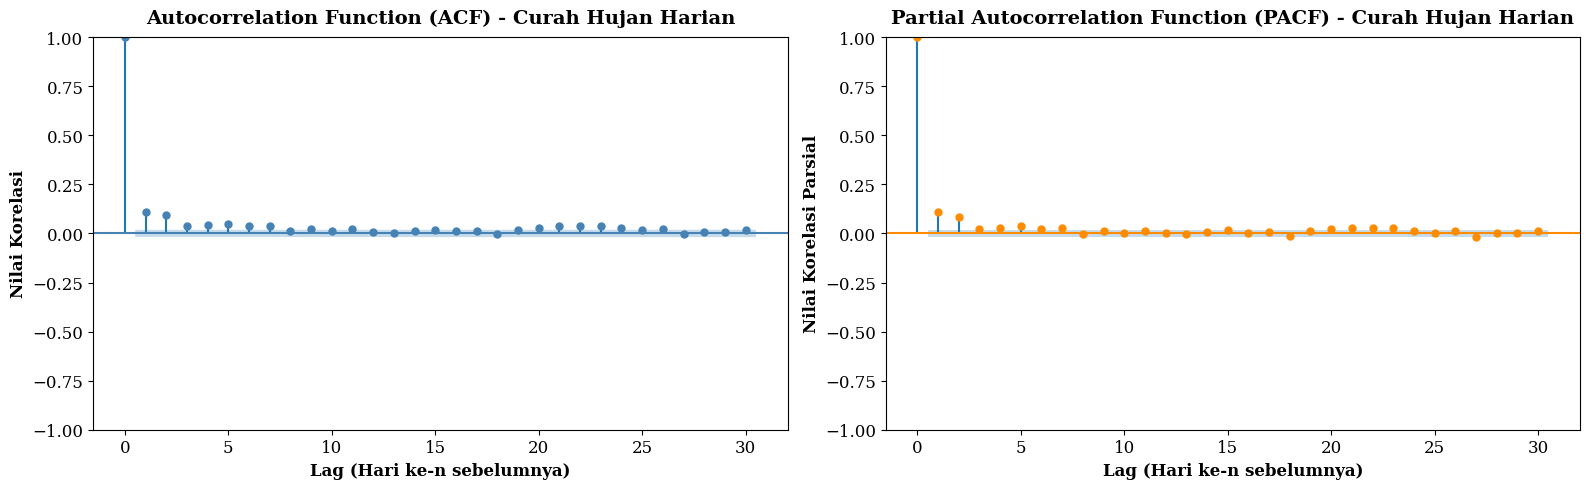

In [ ]:
# ACF dan PACF CH BMKG
# =========================================================
# PENGATURAN GAYA VISUALISASI (TIMES NEW ROMAN & TYPOGRAPHY)
# =========================================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
# Menggunakan target observasi BMKG (rain) dari df_merged
ts_data = df_merged['rain'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# =========================================================
# PLOT ACF (Autocorrelation Function)
# =========================================================
# Konfigurasi ketebalan garis (vlines) dan ukuran titik (marker)
vlines_style_acf = {"linewidth": 2.5, "colors": "steelblue"}
marker_style_acf = {"markersize": 7, "color": "steelblue", "markeredgecolor": "steelblue"}


# Plot ACF (Autocorrelation Function)
# Melihat korelasi langsung dan tidak langsung hingga 30 hari ke belakang
plot_acf(ts_data, lags=30, ax=axes[0], color='steelblue')
axes[0].set_title('Autocorrelation Function (ACF) - Curah Hujan Harian', fontweight='bold', pad=10)
axes[0].set_xlabel('Lag (Hari ke-n sebelumnya)', fontweight='bold')
axes[0].set_ylabel('Nilai Korelasi', fontweight='bold')
axes[0].grid(False)

# Plot PACF (Partial Autocorrelation Function)
# Melihat korelasi MURNI langsung (tanpa efek domino dari hari-hari perantaranya)
plot_pacf(ts_data, lags=30, ax=axes[1], color='darkorange', method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF) - Curah Hujan Harian', fontweight='bold', pad=10)
axes[1].set_xlabel('Lag (Hari ke-n sebelumnya)', fontweight='bold')
axes[1].set_ylabel('Nilai Korelasi Parsial', fontweight='bold')
axes[1].grid(False)

plt.tight_layout()
plt.show()

## ACF dan PACF SST

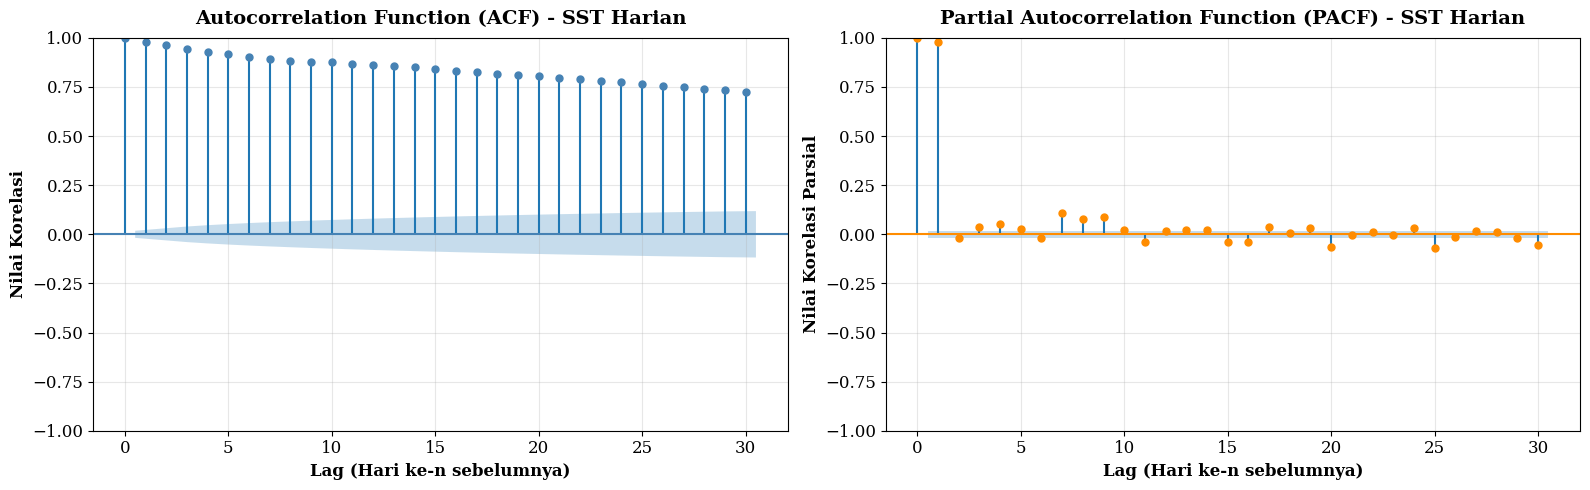

In [ ]:
# Menggunakan data dari df_merged
# =========================================================
# PENGATURAN GAYA VISUALISASI (TIMES NEW ROMAN & TYPOGRAPHY)
# =========================================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

sst_ts_data = df_merged['sst_avg'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# =========================================================
# PLOT ACF (Autocorrelation Function)
# =========================================================
# Konfigurasi ketebalan garis (vlines) dan ukuran titik (marker)
vlines_style_acf = {"linewidth": 2.5, "colors": "steelblue"}
marker_style_acf = {"markersize": 7, "color": "steelblue", "markeredgecolor": "steelblue"}

# Plot ACF (Autocorrelation Function)
# Melihat korelasi langsung dan tidak langsung hingga 30 hari ke belakang
plot_acf(sst_ts_data, lags=30, ax=axes[0], color='steelblue')
axes[0].set_title('Autocorrelation Function (ACF) - SST Harian', fontweight='bold', pad=10)
axes[0].set_xlabel('Lag (Hari ke-n sebelumnya)', fontweight='bold')
axes[0].set_ylabel('Nilai Korelasi', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot PACF (Partial Autocorrelation Function)
# Melihat korelasi MURNI langsung (tanpa efek domino dari hari-hari perantaranya)
plot_pacf(sst_ts_data, lags=30, ax=axes[1], color='darkorange', method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF) - SST Harian', fontweight='bold', pad=10)
axes[1].set_xlabel('Lag (Hari ke-n sebelumnya)', fontweight='bold')
axes[1].set_ylabel('Nilai Korelasi Parsial', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## ACF dan PACF U Wind


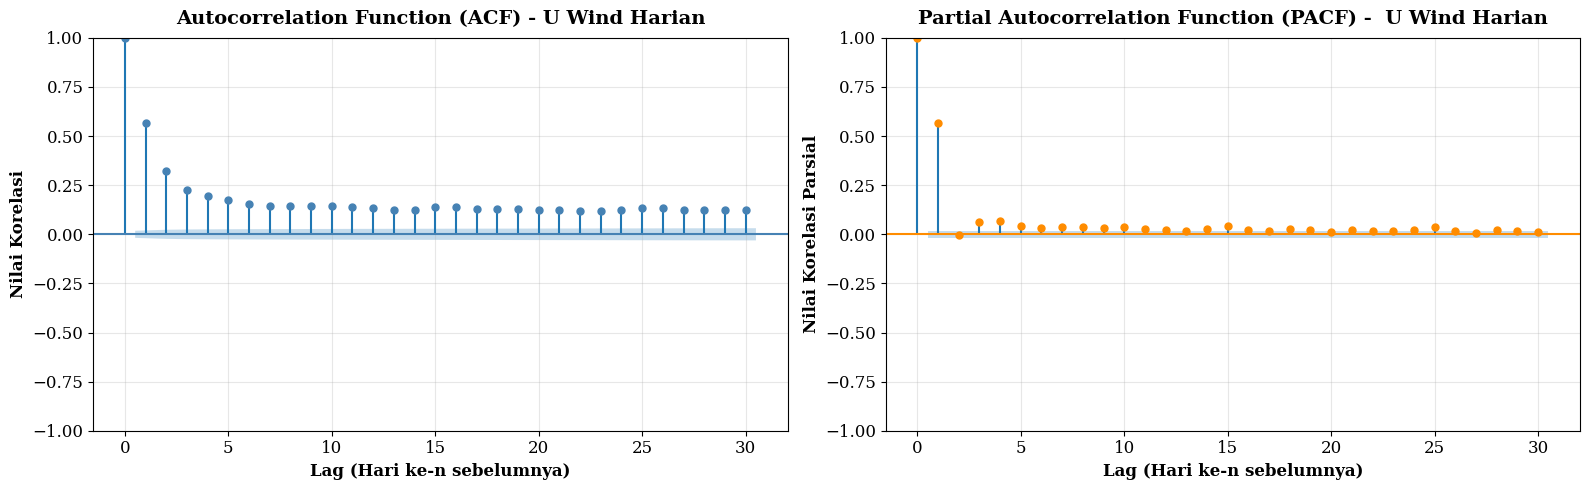

In [ ]:
# Menggunakan data dari df_merged
# Menggunakan data dari df_merged
# =========================================================
# PENGATURAN GAYA VISUALISASI (TIMES NEW ROMAN & TYPOGRAPHY)
# =========================================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

uwind_ts_data = df_merged['u_wind'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# =========================================================
# PLOT ACF (Autocorrelation Function)
# =========================================================
# Konfigurasi ketebalan garis (vlines) dan ukuran titik (marker)
vlines_style_acf = {"linewidth": 2.5, "colors": "steelblue"}
marker_style_acf = {"markersize": 7, "color": "steelblue", "markeredgecolor": "steelblue"}

# Plot ACF (Autocorrelation Function)
# Melihat korelasi langsung dan tidak langsung hingga 30 hari ke belakang
plot_acf(uwind_ts_data, lags=30, ax=axes[0], color='steelblue')
axes[0].set_title('Autocorrelation Function (ACF) - U Wind Harian', fontweight='bold', pad=10)
axes[0].set_xlabel('Lag (Hari ke-n sebelumnya)', fontweight='bold')
axes[0].set_ylabel('Nilai Korelasi', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot PACF (Partial Autocorrelation Function)
# Melihat korelasi MURNI langsung (tanpa efek domino dari hari-hari perantaranya)
plot_pacf(uwind_ts_data, lags=30, ax=axes[1], color='darkorange', method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF) -  U Wind Harian', fontweight='bold', pad=10)
axes[1].set_xlabel('Lag (Hari ke-n sebelumnya)', fontweight='bold')
axes[1].set_ylabel('Nilai Korelasi Parsial', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## ACF dan PACF V WInd


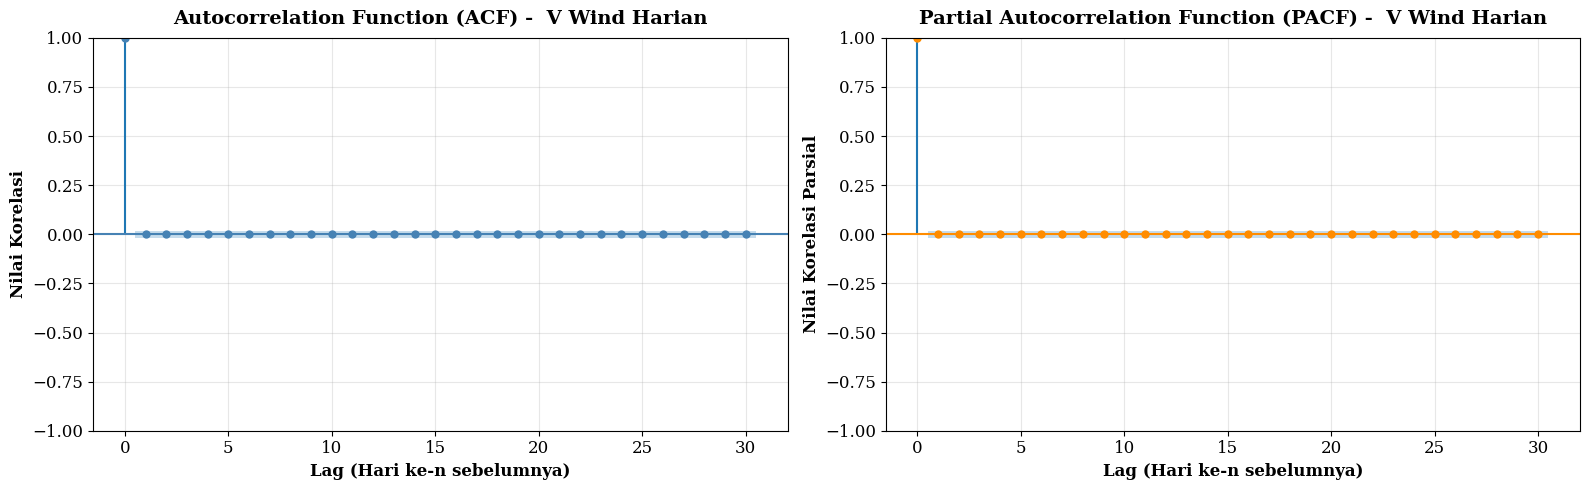

In [ ]:
# Menggunakan data dari df_merged
# =========================================================
# PENGATURAN GAYA VISUALISASI (TIMES NEW ROMAN & TYPOGRAPHY)
# =========================================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

vwind_ts_data = df_merged['v_wind'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# =========================================================
# PLOT ACF (Autocorrelation Function)
# =========================================================
# Konfigurasi ketebalan garis (vlines) dan ukuran titik (marker)
vlines_style_acf = {"linewidth": 2.5, "colors": "steelblue"}
marker_style_acf = {"markersize": 7, "color": "steelblue", "markeredgecolor": "steelblue"}

# Plot ACF (Autocorrelation Function)
# Melihat korelasi langsung dan tidak langsung hingga 30 hari ke belakang
plot_acf(vwind_ts_data, lags=30, ax=axes[0], color='steelblue')
axes[0].set_title('Autocorrelation Function (ACF) -  V Wind Harian', fontweight='bold', pad=10)
axes[0].set_xlabel('Lag (Hari ke-n sebelumnya)', fontweight='bold')
axes[0].set_ylabel('Nilai Korelasi', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot PACF (Partial Autocorrelation Function)
# Melihat korelasi MURNI langsung (tanpa efek domino dari hari-hari perantaranya)
plot_pacf(vwind_ts_data, lags=30, ax=axes[1], color='darkorange', method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF) -  V Wind Harian', fontweight='bold', pad=10)
axes[1].set_xlabel('Lag (Hari ke-n sebelumnya)', fontweight='bold')
axes[1].set_ylabel('Nilai Korelasi Parsial', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Identifikasi Ekstrem


=== VISUALISASI TIME SERIES & IDENTIFIKASI EKSTREM ===

Jumlah hari hujan ekstrem (>150 mm): 6
Contoh kejadian ekstrem:
            date   rain  precip_chirps
2899  1998-12-09  209.0        15.6368
3616  2000-11-25  209.0         1.7717
9094  2015-11-25  181.7         8.1093
11113 2021-06-05  165.2         0.0000
11529 2022-07-26  209.0         3.0934


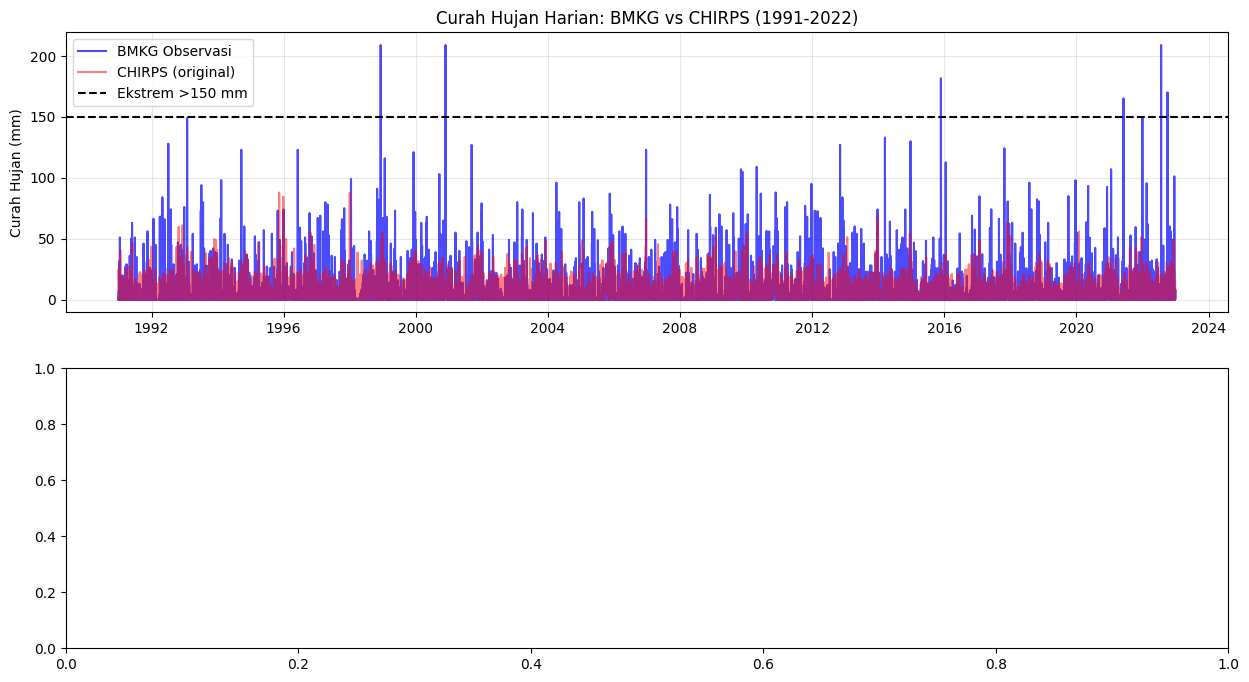

In [ ]:
# %% 4. Visualisasi awal: time series curah hujan & identifikasi ekstrem
print("\n=== VISUALISASI TIME SERIES & IDENTIFIKASI EKSTREM ===\n")

# Tentukan ambang batas ekstrem (misal persentil 99 atau >100 mm/hari)
threshold_extreme = 150  # mm/hari, bisa disesuaikan dengan data
extreme_days = df_merged[df_merged['rain'] > threshold_extreme]
print(f"Jumlah hari hujan ekstrem (>{threshold_extreme} mm): {len(extreme_days)}")
print("Contoh kejadian ekstrem:")
print(extreme_days[['date', 'rain', 'precip_chirps']].head())

# Plot time series
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].plot(df_merged['date'], df_merged['rain'], color='blue', alpha=0.7, label='BMKG Observasi')
axes[0].plot(df_merged['date'], df_merged['precip_chirps'], color='red', alpha=0.5, label='CHIRPS (original)')
axes[0].axhline(y=threshold_extreme, color='black', linestyle='--', label=f'Ekstrem >{threshold_extreme} mm')
axes[0].set_title('Curah Hujan Harian: BMKG vs CHIRPS (1991-2022)')
axes[0].set_ylabel('Curah Hujan (mm)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


##Identifikasi Ekstrem detail periode 2021–2022

In [ ]:
# Zoom ke periode 2021-2022 untuk melihat lebih detail
mask_2021 = (df_merged['date'] >= '2021-01-01') & (df_merged['date'] <= '2022-12-31')
axes[1].plot(df_merged.loc[mask_2021, 'date'], df_merged.loc[mask_2021, 'rain'], color='blue', alpha=0.7, label='BMKG')
axes[1].plot(df_merged.loc[mask_2021, 'date'], df_merged.loc[mask_2021, 'precip_chirps'], color='red', alpha=0.5, label='CHIRPS')
axes[1].axhline(y=threshold_extreme, color='black', linestyle='--')
axes[1].set_title('Curah Hujan (2021-2022)')
axes[1].set_ylabel('mm')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

#Koreksi Bias QM


=== KOREKSI BIAS CHIRPS DENGAN QUANTILE MAPPING ===



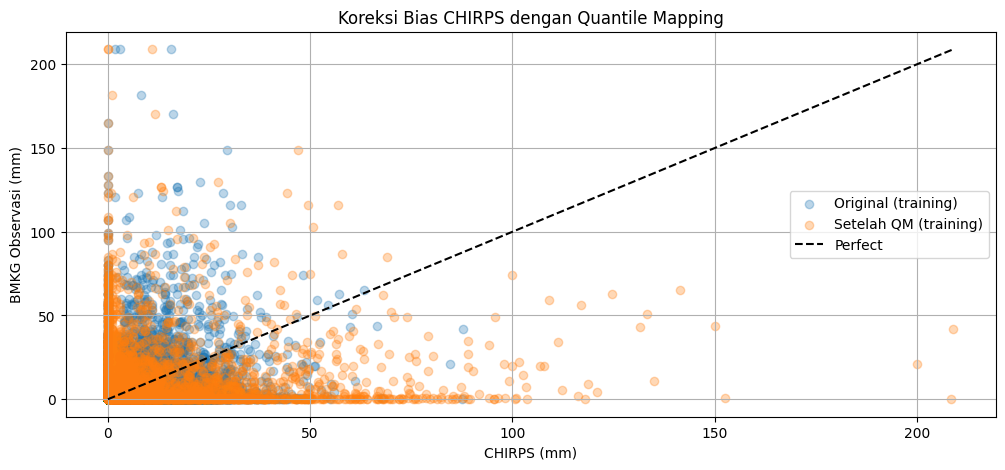

In [ ]:
# %% 5. Koreksi bias CHIRPS dengan Quantile Mapping (menggunakan data 1991-2022)
print("\n=== KOREKSI BIAS CHIRPS DENGAN QUANTILE MAPPING ===\n")

# Gunakan data periode 1991-2022 untuk training koreksi
df_train = df_merged[df_merged['date'] <= '2022-12-31'].copy()
df_train = df_train.dropna(subset=['rain', 'precip_chirps'])

# Quantile Mapping: memetakan distribusi CHIRPS ke distribusi BMKG
# Metode sederhana: hitung quantile bins, lalu interpolasi
n_quantiles = 100  # jumlah quantile
quantiles = np.linspace(0, 1, n_quantiles+1)

# Hitung nilai CHIRPS dan BMKG pada setiap quantile
chirps_quantiles = np.quantile(df_train['precip_chirps'], quantiles)
bmkg_quantiles = np.quantile(df_train['rain'], quantiles)

# Fungsi mapping: untuk nilai CHIRPS, cari quantile-nya lalu interpolasi ke nilai BMKG
def quantile_mapping(x, x_q, y_q):
    # x: nilai CHIRPS yang akan dikoreksi
    # x_q, y_q: pasangan quantile dari training
    return np.interp(x, x_q, y_q)

# Terapkan koreksi ke seluruh data CHIRPS (termasuk 2023-2025)
df_merged['precip_chirps_corrected'] = quantile_mapping(df_merged['precip_chirps'].values,
                                                         chirps_quantiles, bmkg_quantiles)

# Pastikan tidak negatif
df_merged['precip_chirps_corrected'] = df_merged['precip_chirps_corrected'].clip(lower=0)

# Apply the correction to df_train specifically for plotting the training data
# This ensures that df_train has the 'precip_chirps_corrected' column
df_train['precip_chirps_corrected'] = quantile_mapping(df_train['precip_chirps'].values,
                                                       chirps_quantiles, bmkg_quantiles)
df_train['precip_chirps_corrected'] = df_train['precip_chirps_corrected'].clip(lower=0)

# Visualisasi hasil koreksi
plt.figure(figsize=(12,5))
plt.scatter(df_train['precip_chirps'], df_train['rain'], alpha=0.3, label='Original (training)')
plt.scatter(df_train['precip_chirps_corrected'], df_train['rain'], alpha=0.3, label='Setelah QM (training)')
plt.plot([0, df_train[['rain', 'precip_chirps']].max().max()],
         [0, df_train[['rain', 'precip_chirps']].max().max()], 'k--', label='Perfect')
plt.xlabel('CHIRPS (mm)')
plt.ylabel('BMKG Observasi (mm)')
plt.title('Koreksi Bias CHIRPS dengan Quantile Mapping')
plt.legend()
plt.grid(True)
plt.show()

##Metrik sebelum dan sesudah QM

In [ ]:
# Hitung metrik sebelum dan sesudah koreksi pada data training
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def eval_metrics(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    cc = np.corrcoef(y_true, y_pred)[0,1]
    print(f"{name}: RMSE={rmse:.2f}, MAE={mae:.2f}, R²={r2:.2f}, CC={cc:.2f}")
    return rmse, mae, r2, cc

print("\nEvaluasi pada data training (1991-2022):")
eval_metrics(df_train['rain'], df_train['precip_chirps'], "CHIRPS Original")
eval_metrics(df_train['rain'], df_train['precip_chirps_corrected'], "CHIRPS QM")



Evaluasi pada data training (1991-2022):
CHIRPS Original: RMSE=14.14, MAE=7.98, R²=-0.20, CC=0.18
CHIRPS QM: RMSE=16.54, MAE=7.20, R²=-0.65, CC=0.16


(np.float64(16.54252989408415),
 7.1958324219533,
 -0.6476578308930023,
 np.float64(0.162973317421442))

#Langsung Normalisasi ajalahh

#Normalisasi data

In [ ]:
# %% 6. Normalisasi data (MinMaxScaler) - untuk fitur dan target
print("\n=== NORMALISASI DATA (MinMaxScaler) ===\n")

# Pilih fitur yang akan digunakan: tmin, tmax, tavg, RH, precip_chirps_corrected, dan nanti ditambah lag
# Untuk sementara kita normalisasi per kolom
features = ['tmin', 'tmax', 'tavg', 'RH', 'precip_chirps']
target = 'rain'

# Simpan min-max untuk inverse transform nanti
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit scaler pada data training (1991-2022)
df_train_scaled = df_train.copy()
df_train_scaled[features] = scaler_X.fit_transform(df_train[features])
df_train_scaled[target] = scaler_y.fit_transform(df_train[[target]])

# Untuk data full (termasuk 2023-2025) gunakan scaler yang sudah di-fit
df_full = df_merged.copy()
df_full[features] = scaler_X.transform(df_full[features])
df_full[target] = scaler_y.transform(df_full[[target]])

print("Normalisasi selesai. Rentang data setelah normalisasi:")
print("Fitur:", df_full[features].min().min(), "-", df_full[features].max().max())
print("Target:", df_full[target].min(), "-", df_full[target].max())



=== NORMALISASI DATA (MinMaxScaler) ===

Normalisasi selesai. Rentang data setelah normalisasi:
Fitur: 0.0 - 1.0
Target: 0.0 - 1.0


#Lanjutan Preprocessing:
Fitur Lag, Rolling, Split Data, dan Persiapan LSTM
Input: df_merged (sudah dinormalisasi atau belum? Kita akan gunakan data asli (belum normalisasi)
       untuk membuat lag, lalu normalisasi setelah lag. Tapi lebih mudah: buat lag dari target asli,
       lalu normalisasi semua fitur (termasuk lag) bersama-sama.
Namun, agar konsisten dengan praktikum, kita akan:
- Buat lag dan rolling dari target (rain) yang masih dalam skala asli.
- Gabungkan dengan fitur lain (tmin, tmax, tavg, RH, precip_chirps) yang juga skala asli.
- Kemudian lakukan normalisasi MinMax pada semua fitur dan target.
- Lalu split.

#Fungsi Butterworth Filter

In [ ]:
# ==========================================
# 2.5 PENYARINGAN SINYAL (BUTTERWORTH FILTER)
# ==========================================
print("\n=== APLIKASI BUTTERWORTH FILTER ===")

def apply_butterworth(data, cutoff_days, order=3):
    """
    Fungsi untuk mengaplikasikan Low-Pass Butterworth Filter.
    - data: array/series pandas yang akan difilter
    - cutoff_days: menyaring fluktuasi acak yang siklusnya lebih cepat dari X hari
    - order: ketajaman filter (biasanya 2 atau 3 cukup untuk data lingkungan)
    """
    fs = 1.0  # Frekuensi sampling (1 data per hari)
    nyq = 0.5 * fs  # Frekuensi Nyquist

    # Frekuensi cutoff (1 / jumlah hari siklus)
    cutoff_freq = 1.0 / cutoff_days
    normal_cutoff = cutoff_freq / nyq

    # Buat desain filter Butterworth
    b, a = butter(order, normal_cutoff, btype='low', analog=False)

    # Aplikasikan filter dua arah (filtfilt) agar tidak ada pergeseran fase (waktu)
    filtered_data = filtfilt(b, a, data)

    # Cegah nilai curah hujan menjadi negatif akibat perhitungan matematis filter
    filtered_data = np.maximum(filtered_data, 0)
    return filtered_data

# Aplikasikan filter pada CHIRPS untuk membuang noise satelit harian
# Kita menggunakan cutoff 3 hari (menyaring fluktuasi bising di bawah 3 hari)
df_merged['precip_chirps_filtered'] = apply_butterworth(df_merged['precip_chirps'], cutoff_days=3, order=3)

# Kita juga buat versi filter dari observasi BMKG khusus untuk dijadikan input fitur masa lalu (lag)
df_merged['rain_filtered'] = apply_butterworth(df_merged['rain'], cutoff_days=3, order=3)

print("Fitur filter berhasil ditambahkan!")


=== APLIKASI BUTTERWORTH FILTER ===
Fitur filter berhasil ditambahkan!


## Viz hasil filter

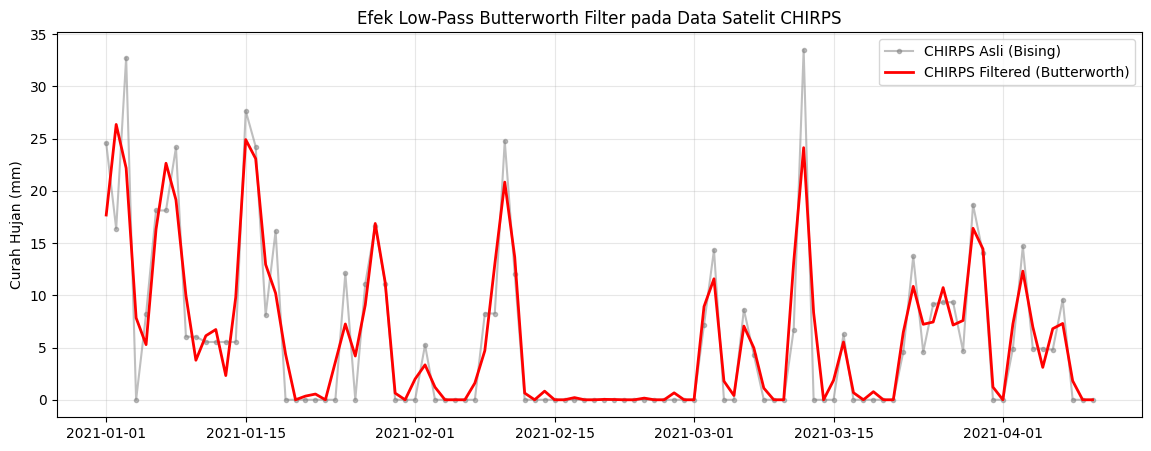

In [ ]:
# Visualisasi efek Butterworth Filter pada CHIRPS (Zoom untuk 100 hari pertama di tahun 2021)
mask_plot = (df_merged['date'] >= '2021-01-01') & (df_merged['date'] <= '2021-04-10')

plt.figure(figsize=(14, 5))
plt.plot(df_merged.loc[mask_plot, 'date'], df_merged.loc[mask_plot, 'precip_chirps'],
         color='gray', alpha=0.5, label='CHIRPS Asli (Bising)', marker='.')
plt.plot(df_merged.loc[mask_plot, 'date'], df_merged.loc[mask_plot, 'precip_chirps_filtered'],
         color='red', linewidth=2, label='CHIRPS Filtered (Butterworth)')
plt.title('Efek Low-Pass Butterworth Filter pada Data Satelit CHIRPS')
plt.ylabel('Curah Hujan (mm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Lag and Rolling

In [ ]:
# %% 7. Pembuatan fitur lag (1-10) dan rolling statistics
print("\n=== PEMBUATAN FITUR LAG & ROLLING STATISTICS ===\n")

print("\n=== PEMBUATAN FITUR LAG & ROLLING STATISTICS ===\n")
df_model = df_merged.copy()

# Dictionary untuk menentukan jumlah lag optimal masing-masing variabel
# berdasarkan analisis PACF
lag_dict = {
    #'rain': 1,             # Target
    #'precip_chirps': 1,    # Samakan dengan target
    'rain_filtered': 1,            # Gunakan versi mulus/filtered sebagai pengingat masa lalu
    'precip_chirps_filtered': 1,   # Gunakan CHIRPS yang sudah dibersihkan noise-nya
    'u_wind': 1,           # Dari PACF menembus hingga lag 3
    'v_wind': 1,           # Dari PACF menembus hingga lag 3
    'sst_avg': 1,          # PACF SST drop drastis setelah lag 1
    'RH': 1,
    'tavg': 1
}

# Buat lag sesuai dictionary di atas
for col, max_lag in lag_dict.items():
    if col in df_model.columns:
        for lag in range(1, max_lag + 1):
            df_model[f'{col}_lag{lag}'] = df_model[col].shift(lag)

# Hapus baris NA akibat proses lag & rolling
df_model = df_model.dropna().reset_index(drop=True)
# Hapus baris NA akibat proses lag & rolling
df_model = df_model.dropna().reset_index(drop=True)

print(f"Bentuk data setelah penambahan fitur lag dan rolling: {df_model.shape}")


=== PEMBUATAN FITUR LAG & ROLLING STATISTICS ===


=== PEMBUATAN FITUR LAG & ROLLING STATISTICS ===

Bentuk data setelah penambahan fitur lag dan rolling: (11685, 19)


#Normalisasi MinMax

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# REVISI 4. NORMALISASI DATA (MinMaxScaler)
# ==========================================
print("\n=== NORMALISASI DATA (MinMaxScaler) ===")

# PERBAIKAN: Hapus variabel hari H.
# Model HANYA menggunakan data dari hari-hari sebelumnya (lag) dan tren (rolling)
feature_cols = [col for col in df_model.columns if 'lag' in col or 'rolling' in col]
target_col = 'rain'

X = df_model[feature_cols]
y = df_model[target_col]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()

df_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
df_scaled[target_col] = y_scaled
df_scaled['date'] = df_model['date'].values


=== NORMALISASI DATA (MinMaxScaler) ===


#Time-based Split

In [ ]:
# ==================================================
# 3. Time-based split: Train (1991-2019), Validation (2020-2021), Test (2022)
# ==================================================
print("\n=== TIME-BASED SPLIT ===")
print("\n=== TIME-BASED SPLIT ===")

train_mask = (df_scaled['date'] >= '1991-01-01') & (df_scaled['date'] <= '2019-12-31')
val_mask   = (df_scaled['date'] >= '2020-01-01') & (df_scaled['date'] <= '2021-12-31')
test_mask  = (df_scaled['date'] >= '2022-01-01') & (df_scaled['date'] <= '2022-12-31')

X_train = df_scaled[train_mask][feature_cols]
y_train = df_scaled[train_mask][target_col]
X_val = df_scaled[val_mask][feature_cols]
y_val = df_scaled[val_mask][target_col]
X_test = df_scaled[test_mask][feature_cols]
y_test = df_scaled[test_mask][target_col]

print(f"Train: {X_train.shape[0]} sampel")
print(f"Test: {X_test.shape[0]} sampel")


=== TIME-BASED SPLIT ===

=== TIME-BASED SPLIT ===
Train: 10591 sampel
Test: 363 sampel


#Eksplorasi kejadian ekstrem

In [ ]:
# ==================================================
# 4. Eksplorasi kejadian ekstrem di validation & test set (dalam skala asli)
# ==================================================
print("\n=== EKSPLORASI KEJADIAN EKSTREM (RAIN >150 mm) ===")

# Ambil data asli (belum scaling) untuk identifikasi ekstrem
df_original = df.copy()  # di sini rain dalam mm asli

threshold = 150  # mm/hari

# Ekstrem di validation set (2020-2021)
val_extreme = df_original[(df_original['date'] >= '2020-01-01') & (df_original['date'] <= '2021-12-31') & (df_original['rain'] > threshold)]
print(f"\nJumlah hari ekstrem di Validation set (2020-2021): {len(val_extreme)}")
if len(val_extreme) > 0:
    print(val_extreme[['date', 'rain']].to_string(index=False))

# Ekstrem di test set (2022)
test_extreme = df_original[(df_original['date'] >= '2022-01-01') & (df_original['date'] <= '2022-12-31') & (df_original['rain'] > threshold)]
print(f"\nJumlah hari ekstrem di Test set (2022): {len(test_extreme)}")
if len(test_extreme) > 0:
    print(test_extreme[['date', 'rain']].to_string(index=False))

# Jika tidak ada kejadian ekstrem, kita bisa menurunkan threshold atau menggunakan persentil 99
if len(val_extreme) == 0 and len(test_extreme) == 0:
    print("\nTidak ada hari dengan rain >150 mm di validation/test set. Menggunakan persentil 99...")
    p99 = np.percentile(df_original['rain'], 99)
    print(f"Persentil 99: {p99:.1f} mm")
    val_extreme_p99 = df_original[(df_original['date'] >= '2020-01-01') & (df_original['date'] <= '2021-12-31') & (df_original['rain'] > p99)]
    test_extreme_p99 = df_original[(df_original['date'] >= '2022-01-01') & (df_original['date'] <= '2022-12-31') & (df_original['rain'] > p99)]
    print(f"Jumlah ekstrem (>{p99:.1f}) di validation: {len(val_extreme_p99)}")
    print(f"Jumlah ekstrem (>{p99:.1f}) di test: {len(test_extreme_p99)}")


=== EKSPLORASI KEJADIAN EKSTREM (RAIN >150 mm) ===

Jumlah hari ekstrem di Validation set (2020-2021): 1
      date  rain
2021-06-05 165.2

Jumlah hari ekstrem di Test set (2022): 2
      date  rain
2022-07-26 209.0
2022-10-05 170.1


#LSTM Prep

In [ ]:
# 5. Siapkan data untuk LSTM (sequence 3D)
# ==================================================
print("\n=== PERSIAPAN DATA LSTM (SEQUENCE) ===")
look_back = 3  # <-- PERBAIKAN: Ubah angka 10 menjadi 3 di sini!
def create_sequences(X, y, look_back):
    X_seq, y_seq = [], []
    for i in range(len(X) - look_back):
        X_seq.append(X.iloc[i:i+look_back].values)
        y_seq.append(y.iloc[i+look_back])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, look_back)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, look_back)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, look_back)

# Menyimpan Data ke Pickle
data_for_model = {
    'X_train': X_train, 'y_train': y_train, 'X_val': X_val, 'y_val': y_val, 'X_test': X_test, 'y_test': y_test,
    'X_train_seq': X_train_seq, 'y_train_seq': y_train_seq, 'X_val_seq': X_val_seq, 'y_val_seq': y_val_seq, 'X_test_seq': X_test_seq, 'y_test_seq': y_test_seq,
    'scaler_y': scaler_y, 'feature_cols': feature_cols, 'look_back': look_back
}

with open('data_for_model.pkl', 'wb') as f:
    pickle.dump(data_for_model, f)


=== PERSIAPAN DATA LSTM (SEQUENCE) ===


#Visualisasi eksplorasi kejadian ekstrem

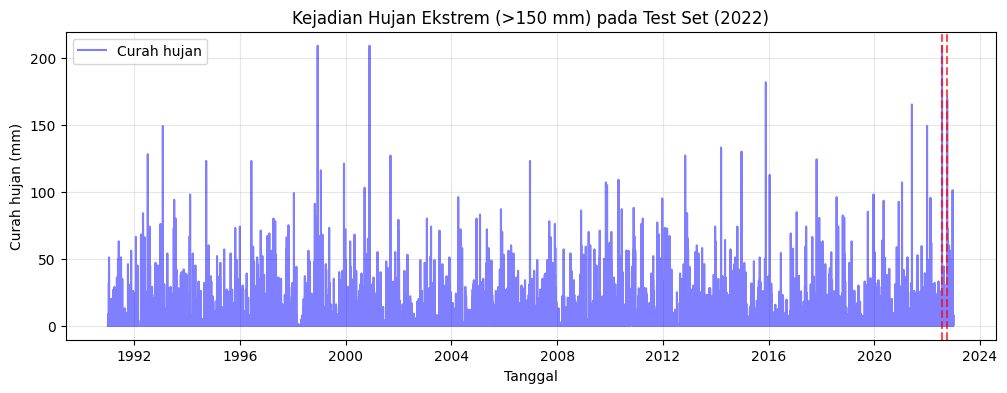


=== SEMUA TAHAP PREPROCESSING SELESAI ===
Sekarang Anda dapat melanjutkan ke tahap pemodelan XGBoost dan LSTM.


In [ ]:
# ==================================================
# 6. Visualisasi singkat kejadian ekstrem di test set
# ==================================================

# Re-define df_original and test_extreme for visualization
df_original = df_merged.copy() # df_merged is available from previous steps
threshold = 150 # mm/hari, as defined in previous cell
test_extreme = df_original[(df_original['date'] >= '2022-01-01') & (df_original['date'] <= '2022-12-31') & (df_original['rain'] > threshold)]

if len(test_extreme) > 0:
    plt.figure(figsize=(12,4))
    plt.plot(df_original['date'], df_original['rain'], color='blue', alpha=0.5, label='Curah hujan')
    for _, row in test_extreme.iterrows():
        plt.axvline(x=row['date'], color='red', linestyle='--', alpha=0.7)
    plt.title('Kejadian Hujan Ekstrem (>150 mm) pada Test Set (2022)')
    plt.xlabel('Tanggal')
    plt.ylabel('Curah hujan (mm)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print("\n=== SEMUA TAHAP PREPROCESSING SELESAI ===")
print("Sekarang Anda dapat melanjutkan ke tahap pemodelan XGBoost dan LSTM.")

#Modeling: XGBoost dan LSTM
- Load data dari pickle
- XGBoost baseline + tuning (RandomizedSearchCV)
- LSTM baseline + tuning
- Prediksi validation & test
- Evaluasi metrik
- Simpan model terbaik

##Load data

In [ ]:
# %% Load data yang sudah disiapkan
print("=== LOAD DATA ===")
with open('data_for_model.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']
X_test = data['X_test']
y_test = data['y_test']
X_train_seq = data['X_train_seq']
y_train_seq = data['y_train_seq']
X_val_seq = data['X_val_seq']
y_val_seq = data['y_val_seq']
X_test_seq = data['X_test_seq']
y_test_seq = data['y_test_seq']
scaler_y = data['scaler_y']
feature_cols = data['feature_cols']
look_back = data['look_back']

print(f"Data loaded. Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")
print(f"LSTM sequences - Train: {X_train_seq.shape}, Val: {X_val_seq.shape}, Test: {X_test_seq.shape}")

# Fungsi evaluasi
def evaluate(y_true, y_pred, name="Model"):
    # Inverse transform ke skala asli (mm)
    y_true_inv = scaler_y.inverse_transform(y_true.values.reshape(-1,1)).flatten()
    y_pred_inv = scaler_y.inverse_transform(y_pred.reshape(-1,1)).flatten()
    rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
    mae = mean_absolute_error(y_true_inv, y_pred_inv)
    r2 = r2_score(y_true_inv, y_pred_inv)
    cc = np.corrcoef(y_true_inv, y_pred_inv)[0,1]
    print(f"{name}: RMSE={rmse:.2f} mm, MAE={mae:.2f} mm, R²={r2:.4f}, CC={cc:.4f}")
    return rmse, mae, r2, cc

=== LOAD DATA ===
Data loaded. Train shape: (10589, 11), Val shape: (731, 11), Test shape: (363, 11)
LSTM sequences - Train: (10586, 3, 11), Val: (728, 3, 11), Test: (360, 3, 11)


##XGBoost

### XGBoost Baseline

In [ ]:
# ==================================================
# 1. XGBoost Baseline
# ==================================================
print("\n=== XGBOOST BASELINE ===")
xgb_baseline = XGBRegressor(n_estimators=500, random_state=42, verbosity=0)
xgb_baseline.fit(X_train, y_train)

# Prediksi baseline
y_pred_train_xgb_baseline = xgb_baseline.predict(X_train)
y_pred_val_xgb_baseline = xgb_baseline.predict(X_val)
y_pred_test_xgb_baseline = xgb_baseline.predict(X_test)

evaluate(y_train, y_pred_train_xgb_baseline, "XGB Baseline - Train")
evaluate(y_val, y_pred_val_xgb_baseline, "XGB Baseline - Val")
evaluate(y_test, y_pred_test_xgb_baseline, "XGB Baseline - Test")

print("\n=== XGBOOST DENGAN SAMPLE WEIGHTING ===")
# Tentukan threshold ekstrem untuk pembobotan
#threshold_weight = 150.0 # atau 100.0

# Kembalikan y_train ke skala asli sementara untuk menentukan bobot
#y_train_asli = scaler_y.inverse_transform(y_train.values.reshape(-1,1)).flatten()

# Buat array bobot: Jika hujan > threshold, beri bobot 20x lipat lebih besar
# Angka 20 ini bisa kamu ubah-ubah (trial & error, misal 10, 20, atau 50)
#sample_weights = np.where(y_train_asli >= threshold_weight, 20.0, 1.0)

# Masukkan bobot ini ke dalam model saat proses fit
#xgb_weighted = XGBRegressor(n_estimators=500, random_state=42, verbosity=0)
#xgb_weighted.fit(X_train, y_train, sample_weight=sample_weights)

# Prediksi
#y_pred_test_xgb_weighted = xgb_weighted.predict(X_test)
#y_test_pred_xgb_weighted_inv = scaler_y.inverse_transform(y_pred_test_xgb_weighted.reshape(-1,1)).flatten()

# Evaluasi regresi dan kategorikal ulang
#evaluate(y_test, y_pred_test_xgb_weighted, "XGB Weighted - Test")
#print("\n>>> EVALUASI KATEGORI HUJAN LEBAT (> 150 mm) DENGAN WEIGHTING <<<")
#evaluate_meteorological_categorical(y_test_actual, y_test_pred_xgb_weighted_inv, threshold=150.0, model_name="XGB Weighted")


=== XGBOOST BASELINE ===
XGB Baseline - Train: RMSE=0.87 mm, MAE=0.56 mm, R²=0.9952, CC=0.9978
XGB Baseline - Val: RMSE=15.86 mm, MAE=7.47 mm, R²=-0.2614, CC=0.2637
XGB Baseline - Test: RMSE=18.95 mm, MAE=7.95 mm, R²=-0.0014, CC=0.3497

=== XGBOOST DENGAN SAMPLE WEIGHTING ===


### Tuning XGBoost

#### Tune 1

In [ ]:
# Hyperparameter tuning dengan RandomizedSearchCV
print("\n=== XGBoost HYPERPARAMETER TUNING (RandomizedSearchCV) ===")
param_dist = {
    'n_estimators': [100, 300, 500, 700],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

xgb_model = XGBRegressor(random_state=42, verbosity=0)
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train, y_train)

print(f"Best parameters: {random_search.best_params_}")
best_xgb = random_search.best_estimator_


=== XGBoost HYPERPARAMETER TUNING (RandomizedSearchCV) ===
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'subsample': 0.6, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [ ]:
# Prediksi dengan best model
y_pred_train_xgb = best_xgb.predict(X_train)
y_pred_val_xgb = best_xgb.predict(X_val)
y_pred_test_xgb = best_xgb.predict(X_test)

print("\nEvaluasi XGBoost setelah tuning:")
evaluate(y_train, y_pred_train_xgb, "XGB Tuned - Train")
evaluate(y_val, y_pred_val_xgb, "XGB Tuned - Val")
evaluate(y_test, y_pred_test_xgb, "XGB Tuned - Test")

# Simpan model XGBoost terbaik
with open('best_xgb_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)
print("Model XGBoost terbaik disimpan ke 'best_xgb_model.pkl'")


Evaluasi XGBoost setelah tuning:
XGB Tuned - Train: RMSE=10.58 mm, MAE=5.18 mm, R²=0.2866, CC=0.5390
XGB Tuned - Val: RMSE=12.35 mm, MAE=5.98 mm, R²=0.2343, CC=0.4854
XGB Tuned - Test: RMSE=17.21 mm, MAE=7.75 mm, R²=0.1741, CC=0.4179
Model XGBoost terbaik disimpan ke 'best_xgb_model.pkl'


#### Tune 2

In [ ]:
# ==================================================
# REVISI XGBoost HYPERPARAMETER TUNING (RandomizedSearchCV)
# ==================================================
print("\n=== XGBoost HYPERPARAMETER TUNING (Revisi Objective & Scoring) ===")

# Parameter grid disesuaikan agar model tidak terlalu kompleks (cegah overfitting ke data ekstrem)
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5], # Jangan terlalu dalam agar tidak menghafal noise
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0.5, 1, 5],  # L1 Regularization: Ditingkatkan agar model lebih konservatif
    'reg_lambda': [1, 5, 10]   # L2 Regularization: Ditingkatkan untuk meredam tebakan ekstrem palsu
}

# PERBAIKAN UTAMA: Gunakan reg:pseudohubererror agar model tidak panik saat melihat hujan 150 mm
xgb_model = XGBRegressor(objective='reg:pseudohubererror', random_state=42, verbosity=0)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    # PERBAIKAN KEDUA: Gunakan MAE untuk evaluasi tuning, bukan MSE/Squared Error
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train, y_train)

print(f"Best parameters: {random_search.best_params_}")
best_xgb = random_search.best_estimator_

# Prediksi dengan best model
y_pred_train_xgb = best_xgb.predict(X_train)
y_pred_val_xgb = best_xgb.predict(X_val)
y_pred_test_xgb = best_xgb.predict(X_test)

# Mencegah model memprediksi hujan negatif
y_pred_test_xgb = np.maximum(y_pred_test_xgb, 0)

print("\nEvaluasi XGBoost setelah tuning baru:")
evaluate(y_train, y_pred_train_xgb, "XGB Tuned - Train")
evaluate(y_train, y_pred_val_xgb, "XGB Tuned - Val")
evaluate(y_test, y_pred_test_xgb, "XGB Tuned - Test")

# Jalankan ulang evaluasi kategorikal di bawah sini menggunakan y_pred_test_xgb yang baru


=== XGBoost HYPERPARAMETER TUNING (Revisi Objective & Scoring) ===
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0.5, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

Evaluasi XGBoost setelah tuning baru:
XGB Tuned - Train: RMSE=10.24 mm, MAE=4.99 mm, R²=0.3325, CC=0.5855
XGB Tuned - Test: RMSE=17.43 mm, MAE=7.76 mm, R²=0.1531, CC=0.3926


(np.float64(17.426528243940396),
 7.76039960361227,
 0.15314624716906533,
 np.float64(0.39255333794232217))

### Cek XGBoost

<Figure size 1000x600 with 0 Axes>

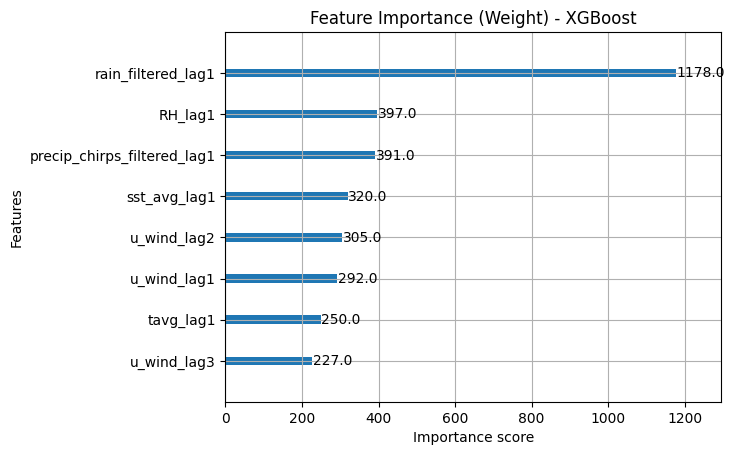

In [ ]:
# Plot Feature Importance XGBoost
plt.figure(figsize=(10, 6))
xgb.plot_importance(best_xgb, max_num_features=10, importance_type='weight')
plt.title('Feature Importance (Weight) - XGBoost')
plt.show()

## LSTM

In [ ]:
# 2. LSTM Baseline + Tuning (sederhana karena waktu)
# ==================================================
print("\n=== LSTM BASELINE ===")
# Arsitektur baseline sederhana
def build_lstm(input_shape, units1=50, units2=25, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential()
    model.add(LSTM(units1, input_shape=input_shape, return_sequences=True))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units2, return_sequences=False))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
    return model

input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
lstm_baseline = build_lstm(input_shape, units1=50, units2=25, dropout_rate=0.2, learning_rate=0.001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_baseline.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[early_stop],
    verbose=1
)


=== LSTM BASELINE ===
Epoch 1/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.0037 - mae: 0.0325 - val_loss: 0.0045 - val_mae: 0.0360
Epoch 2/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0035 - mae: 0.0315 - val_loss: 0.0045 - val_mae: 0.0363
Epoch 3/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0035 - mae: 0.0314 - val_loss: 0.0045 - val_mae: 0.0303
Epoch 4/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0035 - mae: 0.0314 - val_loss: 0.0045 - val_mae: 0.0348
Epoch 5/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0035 - mae: 0.0313 - val_loss: 0.0045 - val_mae: 0.0365
Epoch 6/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0035 - mae: 0.0314 - val_loss: 0.0045 - val_mae: 0.0354
Epoch 7/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0035 - mae: 0.0314 - val_loss: 0.0045 - val_mae: 0.0345
Epoch 8/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0035 - mae: 0.0311 - val_loss: 0.0045 - val_mae: 0.0352
Epoch 9/100
331/331 ━━━

In [ ]:
# Prediksi baseline
y_pred_train_lstm_baseline = lstm_baseline.predict(X_train_seq).flatten()
y_pred_val_lstm_baseline = lstm_baseline.predict(X_val_seq).flatten()
y_pred_test_lstm_baseline = lstm_baseline.predict(X_test_seq).flatten()

print("\nEvaluasi LSTM baseline (pada data sequence):")
evaluate(pd.Series(y_train_seq), y_pred_train_lstm_baseline, "LSTM Baseline - Train")
evaluate(pd.Series(y_val_seq), y_pred_val_lstm_baseline, "LSTM Baseline - Val")
evaluate(pd.Series(y_test_seq), y_pred_test_lstm_baseline, "LSTM Baseline - Test")

331/331 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

Evaluasi LSTM baseline (pada data sequence):
LSTM Baseline - Train: RMSE=12.38 mm, MAE=7.08 mm, R²=0.0236, CC=0.1731
LSTM Baseline - Val: RMSE=13.97 mm, MAE=7.58 mm, R²=0.0190, CC=0.1434
LSTM Baseline - Test: RMSE=18.75 mm, MAE=9.01 mm, R²=0.0163, CC=0.1325


(np.float64(18.75368362657984),
 9.01299368540446,
 0.016253590656927885,
 np.float64(0.13249395496792143))

### Tuning LSTM

In [ ]:
# Hyperparameter tuning sederhana (coba beberapa kombinasi)
print("\n=== LSTM HYPERPARAMETER TUNING (Sederhana) ===")
param_grid_lstm = [
    {'units1': 50, 'units2': 25, 'dropout': 0.2, 'lr': 0.001},
    {'units1': 100, 'units2': 50, 'dropout': 0.3, 'lr': 0.001},
    {'units1': 64, 'units2': 32, 'dropout': 0.2, 'lr': 0.0005},
    {'units1': 128, 'units2': 64, 'dropout': 0.3, 'lr': 0.001}
]

best_val_loss = np.inf
best_lstm_model = None
best_params = None

for params in param_grid_lstm:
    print(f"\nMencoba units1={params['units1']}, units2={params['units2']}, dropout={params['dropout']}, lr={params['lr']}")
    model = build_lstm(input_shape, params['units1'], params['units2'], params['dropout'], params['lr'])
    early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    h = model.fit(
        X_train_seq, y_train_seq,
        epochs=80,
        batch_size=32,
        validation_data=(X_val_seq, y_val_seq),
        callbacks=[early_stop],
        verbose=0
    )
    val_loss = min(h.history['val_loss'])
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_lstm_model = model
        best_params = params
        print(f"  -> Model baru terbaik dengan val_loss={val_loss:.6f}")

print(f"\nParameter LSTM terbaik: {best_params}")


=== LSTM HYPERPARAMETER TUNING (Sederhana) ===

Mencoba units1=50, units2=25, dropout=0.2, lr=0.001
  -> Model baru terbaik dengan val_loss=0.004461

Mencoba units1=100, units2=50, dropout=0.3, lr=0.001

Mencoba units1=64, units2=32, dropout=0.2, lr=0.0005

Mencoba units1=128, units2=64, dropout=0.3, lr=0.001
  -> Model baru terbaik dengan val_loss=0.004404

Parameter LSTM terbaik: {'units1': 128, 'units2': 64, 'dropout': 0.3, 'lr': 0.001}


In [ ]:
# Prediksi dengan model LSTM terbaik
y_pred_train_lstm = best_lstm_model.predict(X_train_seq).flatten()
y_pred_val_lstm = best_lstm_model.predict(X_val_seq).flatten()
y_pred_test_lstm = best_lstm_model.predict(X_test_seq).flatten()

print("\nEvaluasi LSTM setelah tuning:")
evaluate(pd.Series(y_train_seq), y_pred_train_lstm, "LSTM Tuned - Train")
evaluate(pd.Series(y_val_seq), y_pred_val_lstm, "LSTM Tuned - Val")
evaluate(pd.Series(y_test_seq), y_pred_test_lstm, "LSTM Tuned - Test")

# Simpan model LSTM terbaik
best_lstm_model.save('best_lstm_model.h5')
print("Model LSTM terbaik disimpan ke 'best_lstm_model.h5'")

# ==================================================
# 3. Prediksi pada validation & test set (dalam skala asli untuk plot)
# ==================================================
# Inverse transform untuk plotting
y_val_actual = scaler_y.inverse_transform(y_val.values.reshape(-1,1)).flatten()
y_test_actual = scaler_y.inverse_transform(y_test.values.reshape(-1,1)).flatten()

y_val_pred_xgb = scaler_y.inverse_transform(y_pred_val_xgb.reshape(-1,1)).flatten()
y_test_pred_xgb = scaler_y.inverse_transform(y_pred_test_xgb.reshape(-1,1)).flatten()

# Untuk LSTM, y_val_seq dan y_test_seq adalah sequence, kita perlu ambil yang sesuai panjangnya
# Indeks: y_val_seq adalah y_val[look_back:] karena create_sequences. Kita sesuaikan.
y_val_actual_seq = scaler_y.inverse_transform(y_val_seq.reshape(-1,1)).flatten()
y_test_actual_seq = scaler_y.inverse_transform(y_test_seq.reshape(-1,1)).flatten()
y_val_pred_lstm = scaler_y.inverse_transform(y_pred_val_lstm.reshape(-1,1)).flatten()
y_test_pred_lstm = scaler_y.inverse_transform(y_pred_test_lstm.reshape(-1,1)).flatten()


331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 



Evaluasi LSTM setelah tuning:
LSTM Tuned - Train: RMSE=12.17 mm, MAE=6.38 mm, R²=0.0573, CC=0.2397
LSTM Tuned - Val: RMSE=13.87 mm, MAE=6.91 mm, R²=0.0325, CC=0.1863
LSTM Tuned - Test: RMSE=18.58 mm, MAE=8.33 mm, R²=0.0345, CC=0.1991
Model LSTM terbaik disimpan ke 'best_lstm_model.h5'


# Evaluasi Kategorik

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

def evaluate_meteorological_categorical(y_true, y_pred, threshold, model_name="Model"):
    # Klasifikasi: 1 jika curah hujan >= threshold (Kejadian), 0 jika < threshold (Tidak terjadi)
    y_true_cat = (y_true >= threshold).astype(int)
    y_pred_cat = (y_pred >= threshold).astype(int)

    # Menghitung elemen Tabel Kontingensi (Confusion Matrix)
    # tn = True Negatives (Correct Negatives)
    # fp = False Positives (False Alarms)
    # fn = False Negatives (Misses)
    # tp = True Positives (Hits)
    tn, fp, fn, tp = confusion_matrix(y_true_cat, y_pred_cat, labels=[0, 1]).ravel()

    # Hitung Metrik Meteorologi
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    pod = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # Probability of Detection / Hit Rate
    far = fp / (tp + fp) if (tp + fp) > 0 else 0.0  # False Alarm Ratio
    csi = tp / (tp + fn + fp) if (tp + fn + fp) > 0 else 0.0 # Critical Success Index

    print(f"=== Evaluasi {model_name} (Threshold >= {threshold} mm) ===")
    print(f"Hits (Tepat Tebak)       : {tp}")
    print(f"Misses (Gagal Tebak)     : {fn}")
    print(f"False Alarms (Zonk)      : {fp}")
    print(f"Correct Negatives (Aman) : {tn}")
    print(f"---------------------------------------------------")
    print(f"Accuracy : {accuracy:.2%} (Akurasi keseluruhan)")
    print(f"POD      : {pod:.2%} (Dari semua kejadian asli, berapa persen yang berhasil ditebak model?)")
    print(f"FAR      : {far:.2%} (Dari semua peringatan model, berapa persen yang ternyata salah alarm?)")
    print(f"CSI      : {csi:.2%} (Indeks keandalan model tanpa terdistorsi hari tanpa hujan)\n")

    return tp, fn, fp, tn, accuracy, pod, far, csi

# 1. Evaluasi untuk Hujan Biasa (Misal: Hujan > 1 mm)
print(">>> EVALUASI KATEGORI HUJAN BIASA (> 1 mm) <<<")
#evaluate_meteorological_categorical(y_test_actual, y_test_pred_xgb_weighted_inv, threshold=1.0, model_name="XGBoost Baseline")
evaluate_meteorological_categorical(y_test_actual, y_pred_test_xgb_baseline, threshold=1.0, model_name="XGBoost Baseline")
evaluate_meteorological_categorical(y_test_actual, scaler_y.inverse_transform(y_test_pred_xgb.reshape(-1,1)).flatten(), threshold=1.0, model_name="XGBoost Tuned")
evaluate_meteorological_categorical(y_test_actual_seq, scaler_y.inverse_transform(y_pred_test_lstm_baseline.reshape(-1,1)).flatten(), threshold=1.0, model_name="LSTM Baseline")
evaluate_meteorological_categorical(y_test_actual_seq, scaler_y.inverse_transform(y_test_pred_lstm.reshape(-1,1)).flatten(), threshold=1.0, model_name="LSTM Tuned")

# 2. Evaluasi untuk Hujan Lebat/Ekstrem (Misal: Hujan > 50 mm)
print(">>> EVALUASI KATEGORI HUJAN LEBAT (> 150 mm) <<<")
#evaluate_meteorological_categorical(y_test_actual, y_test_pred_xgb_weighted_inv, threshold=150.0, model_name="XGBoost Baseline")
evaluate_meteorological_categorical(y_test_actual, y_pred_test_xgb_baseline, threshold=150.0, model_name="XGBoost Baseline")
evaluate_meteorological_categorical(y_test_actual, scaler_y.inverse_transform(y_test_pred_xgb.reshape(-1,1)).flatten(), threshold=150.0, model_name="XGBoost Tuned")
evaluate_meteorological_categorical(y_test_actual_seq, scaler_y.inverse_transform(y_pred_test_lstm_baseline.reshape(-1,1)).flatten(), threshold=150.0, model_name="LSTM Baseline")
evaluate_meteorological_categorical(y_test_actual_seq, scaler_y.inverse_transform(y_test_pred_lstm.reshape(-1,1)).flatten(), threshold=150.0, model_name="LSTM Tuned")

>>> EVALUASI KATEGORI HUJAN BIASA (> 1 mm) <<<
=== Evaluasi XGBoost Baseline (Threshold >= 1.0 mm) ===
Hits (Tepat Tebak)       : 0
Misses (Gagal Tebak)     : 145
False Alarms (Zonk)      : 0
Correct Negatives (Aman) : 218
---------------------------------------------------
Accuracy : 60.06% (Akurasi keseluruhan)
POD      : 0.00% (Dari semua kejadian asli, berapa persen yang berhasil ditebak model?)
FAR      : 0.00% (Dari semua peringatan model, berapa persen yang ternyata salah alarm?)
CSI      : 0.00% (Indeks keandalan model tanpa terdistorsi hari tanpa hujan)

=== Evaluasi XGBoost Tuned (Threshold >= 1.0 mm) ===
Hits (Tepat Tebak)       : 145
Misses (Gagal Tebak)     : 0
False Alarms (Zonk)      : 218
Correct Negatives (Aman) : 0
---------------------------------------------------
Accuracy : 39.94% (Akurasi keseluruhan)
POD      : 100.00% (Dari semua kejadian asli, berapa persen yang berhasil ditebak model?)
FAR      : 60.06% (Dari semua peringatan model, berapa persen yang ternyata

(np.int64(2),
 np.int64(0),
 np.int64(357),
 np.int64(1),
 np.float64(0.008333333333333333),
 np.float64(1.0),
 np.float64(0.9944289693593314),
 np.float64(0.005571030640668524))

#Viz

=== MEMPERSIAPKAN VISUALISASI DAN TABEL EVALUASI ===



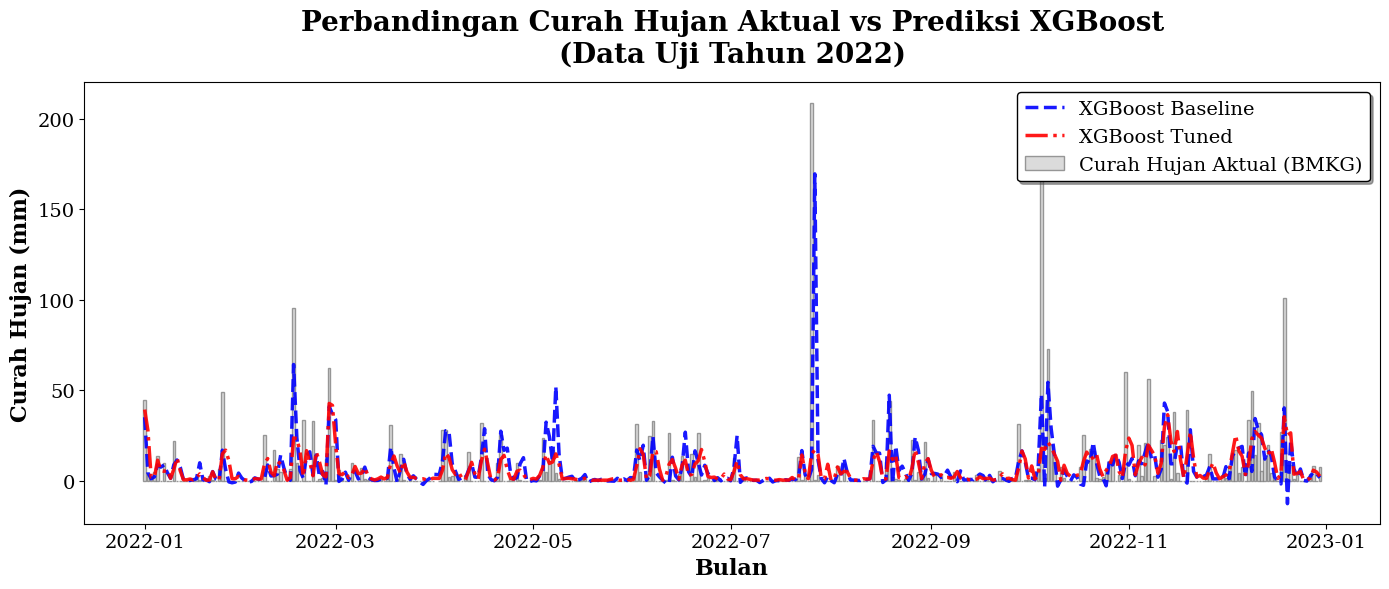

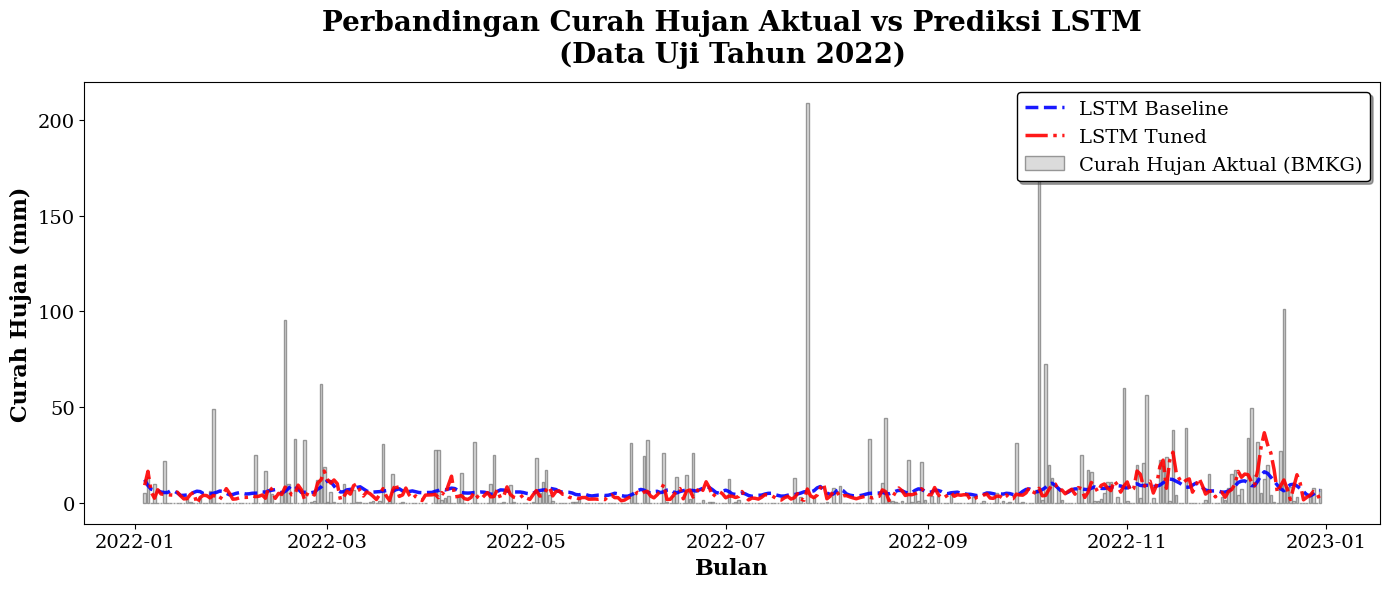


(Catatan: Dua file gambar resolusi tinggi 'Grafik_XGBoost_PPT.png' dan 'Grafik_LSTM_PPT.png' telah tersimpan di direktori dan siap disisipkan ke PPT!)

TABEL EVALUASI STATISTIK (REGRESI)


,Model,RMSE (mm),MAE (mm),R²,CC
0,XGBoost Baseline,18.95,7.95,-0.0014,0.3497
1,XGBoost Tuned,17.21,7.75,0.1741,0.4179
2,LSTM Baseline,18.75,9.01,0.0163,0.1325
3,LSTM Tuned,18.58,8.33,0.0345,0.1991



TABEL EVALUASI KATEGORIKAL (KLASIFIKASI EKSKTREM > 150 mm)


,Model,Threshold,Hits,Misses,False Alarms,Correct Neg,Accuracy (%),POD (%),FAR (%),CSI (%)
0,XGBoost Baseline,> 150.0 mm,0,2,1,360,99.17,0.0,100.0,0.0
1,XGBoost Tuned,> 150.0 mm,0,2,0,361,99.45,0.0,0.0,0.0
2,LSTM Baseline,> 150.0 mm,0,2,0,358,99.44,0.0,0.0,0.0
3,LSTM Tuned,> 150.0 mm,0,2,0,358,99.44,0.0,0.0,0.0



(Catatan: File CSV untuk tabel telah disimpan di direktori Colab)

TABEL EVALUASI KATEGORIKAL (Curah Hujan Harian > 1.0 mm)


,Model,Threshold,Hits,Misses,False Alarms,Correct Neg,Accuracy (%),POD (%),FAR (%),CSI (%)
0,XGBoost Baseline,> 1.0 mm,121,24,121,97,60.06,83.45,50.00,45.49
1,XGBoost Tuned,> 1.0 mm,138,7,139,79,59.78,95.17,50.18,48.59
2,LSTM Baseline,> 1.0 mm,142,0,218,0,39.44,100.00,60.56,39.44
3,LSTM Tuned,> 1.0 mm,142,0,217,1,39.72,100.00,60.45,39.55



(Catatan: File CSV untuk tabel telah disimpan di direktori Colab)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, mean_squared_error, mean_absolute_error, r2_score

print("=== MEMPERSIAPKAN VISUALISASI DAN TABEL EVALUASI ===\n")

# ---------------------------------------------------------
# A. PERSIAPAN DATA (INVERSE TRANSFORM)
# ---------------------------------------------------------
# Pastikan semua data dikembalikan ke skala milimeter (mm)
actual_xgb = scaler_y.inverse_transform(y_test.values.reshape(-1,1)).flatten()
pred_xgb_base = scaler_y.inverse_transform(y_pred_test_xgb_baseline.reshape(-1,1)).flatten()
pred_xgb_tune = scaler_y.inverse_transform(y_pred_test_xgb.reshape(-1,1)).flatten()

actual_lstm = scaler_y.inverse_transform(y_test_seq.reshape(-1,1)).flatten()
pred_lstm_base = scaler_y.inverse_transform(y_pred_test_lstm_baseline.reshape(-1,1)).flatten()
pred_lstm_tune = scaler_y.inverse_transform(y_pred_test_lstm.reshape(-1,1)).flatten()

# Ambil tanggal untuk sumbu X grafik
dates_xgb = df_scaled[test_mask]['date'].values
dates_lstm = df_scaled[test_mask]['date'].values[look_back:]

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# =========================================================
# PENGATURAN GAYA VISUALISASI GLOBAL (UNTUK PRESENTASI PPT)
# =========================================================
# Mengubah font bawaan menjadi keluarga Serif (Times New Roman)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Bitstream Vera Serif']

# =========================================================
# 1. GRAFIK XGBOOST (DIPISAH)
# =========================================================
plt.figure(figsize=(14, 6)) # Proporsi memanjang, cocok untuk slide 16:9

# Plotting dengan garis yang jauh lebih tebal dan kontras warna yang tajam
# Bar chart untuk data aktual (BMKG)
plt.bar(dates_xgb, actual_xgb, color='lightgray', edgecolor='gray', label='Curah Hujan Aktual (BMKG)', alpha=0.8)
#plt.plot(dates_xgb, actual_xgb, label='Actual (BMKG)', color='grey', linewidth=3, alpha=0.7)
plt.plot(dates_xgb, pred_xgb_base, label='XGBoost Baseline', color='blue', linestyle='--', linewidth=2.5, alpha=0.9)
plt.plot(dates_xgb, pred_xgb_tune, label='XGBoost Tuned', color='red', linestyle='-.', linewidth=2.5, alpha=0.9)

# Tipografi Judul dan Label yang besar dan jelas
plt.title('Perbandingan Curah Hujan Aktual vs Prediksi XGBoost\n(Data Uji Tahun 2022)', fontsize=20, fontweight='bold', pad=15)
plt.ylabel('Curah Hujan (mm)', fontsize=16, fontweight='bold')
plt.xlabel('Bulan', fontsize=16, fontweight='bold')

# Memperbesar ukuran angka di sumbu X dan Y
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Legenda dibuat besar dengan latar belakang putih agar tidak tertimpa garis
plt.legend(fontsize=14, loc='upper right', framealpha=1.0, edgecolor='black', shadow=True)

plt.tight_layout()

# Simpan gambar dalam resolusi tinggi (300 DPI) agar tidak pecah di PPT
plt.savefig('Grafik_XGBoost_PPT.png', dpi=300, bbox_inches='tight')
plt.show()

# =========================================================
# 2. GRAFIK LSTM (DIPISAH)
# =========================================================
plt.figure(figsize=(14, 6))

# Plotting
# Bar chart untuk data aktual (BMKG)
plt.bar(dates_lstm, actual_lstm, color='lightgray', edgecolor='gray', label='Curah Hujan Aktual (BMKG)', alpha=0.8)
#plt.plot(dates_lstm, actual_lstm, label='Actual (BMKG)', color='grey', linewidth=3, alpha=0.7)
plt.plot(dates_lstm, pred_lstm_base, label='LSTM Baseline', color='blue', linestyle='--', linewidth=2.5, alpha=0.9)
plt.plot(dates_lstm, pred_lstm_tune, label='LSTM Tuned', color='red', linestyle='-.', linewidth=2.5, alpha=0.9)

# Tipografi
plt.title('Perbandingan Curah Hujan Aktual vs Prediksi LSTM\n(Data Uji Tahun 2022)', fontsize=20, fontweight='bold', pad=15)
plt.ylabel('Curah Hujan (mm)', fontsize=16, fontweight='bold')
plt.xlabel('Bulan', fontsize=16, fontweight='bold')

# Angka Sumbu
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Legenda
plt.legend(fontsize=14, loc='upper right', framealpha=1.0, edgecolor='black', shadow=True)

plt.tight_layout()

# Simpan gambar
plt.savefig('Grafik_LSTM_PPT.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n(Catatan: Dua file gambar resolusi tinggi 'Grafik_XGBoost_PPT.png' dan 'Grafik_LSTM_PPT.png' telah tersimpan di direktori dan siap disisipkan ke PPT!)")

# ---------------------------------------------------------
# FUNGSI BANTUAN UNTUK TABEL
# ---------------------------------------------------------
def get_stats(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    cc = np.corrcoef(y_true, y_pred)[0,1]
    return {"Model": model_name, "RMSE (mm)": round(rmse, 2), "MAE (mm)": round(mae, 2), "R²": round(r2, 4), "CC": round(cc, 4)}

def get_cat_stats(y_true, y_pred, threshold, model_name):
    y_t = (y_true >= threshold).astype(int)
    y_p = (y_pred >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)
    pod = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    far = fp / (tp + fp) if (tp + fp) > 0 else 0.0
    csi = tp / (tp + fn + fp) if (tp + fn + fp) > 0 else 0.0

    return {"Model": model_name, "Threshold": f"> {threshold} mm",
            "Hits": tp, "Misses": fn, "False Alarms": fp, "Correct Neg": tn,
            "Accuracy (%)": round(acc*100, 2), "POD (%)": round(pod*100, 2),
            "FAR (%)": round(far*100, 2), "CSI (%)": round(csi*100, 2)}

# ---------------------------------------------------------
# 2 & 5. TABEL EVALUASI STATISTIK (REGRESI)
# ---------------------------------------------------------
print("\n" + "="*50)
print("TABEL EVALUASI STATISTIK (REGRESI)")
print("="*50)

df_stats = pd.DataFrame([
    get_stats(actual_xgb, pred_xgb_base, "XGBoost Baseline"),
    get_stats(actual_xgb, pred_xgb_tune, "XGBoost Tuned"),
    get_stats(actual_lstm, pred_lstm_base, "LSTM Baseline"),
    get_stats(actual_lstm, pred_lstm_tune, "LSTM Tuned")
])
display(df_stats)

# ---------------------------------------------------------
# 3 & 6. TABEL EVALUASI KATEGORIKAL (KLASIFIKASI)
# ---------------------------------------------------------
print("\n" + "="*50)
print("TABEL EVALUASI KATEGORIKAL (KLASIFIKASI EKSKTREM > 150 mm)")
print("="*50)

# Menggunakan threshold 150 mm sebagai representasi hujan lebat
thresh = 150.0
df_cat = pd.DataFrame([
    get_cat_stats(actual_xgb, pred_xgb_base, thresh, "XGBoost Baseline"),
    get_cat_stats(actual_xgb, pred_xgb_tune, thresh, "XGBoost Tuned"),
    get_cat_stats(actual_lstm, pred_lstm_base, thresh, "LSTM Baseline"),
    get_cat_stats(actual_lstm, pred_lstm_tune, thresh, "LSTM Tuned")
])
display(df_cat)

# Optional: Simpan tabel ke CSV agar mudah disalin ke Word/Excel untuk laporan PBL
df_stats.to_csv("Tabel_Evaluasi_Statistik.csv", index=False)
df_cat.to_csv("Tabel_Evaluasi_Kategorikal.csv", index=False)
print("\n(Catatan: File CSV untuk tabel telah disimpan di direktori Colab)")

# ---------------------------------------------------------
# 3 & 6. TABEL EVALUASI KATEGORIKAL (KLASIFIKASI) CH NORMAL
# ---------------------------------------------------------
print("\n" + "="*50)
print("TABEL EVALUASI KATEGORIKAL (Curah Hujan Harian > 1.0 mm)")
print("="*50)

# Menggunakan threshold 150 mm sebagai representasi hujan lebat
thresh = 1.0
df_1mm = pd.DataFrame([
    get_cat_stats(actual_xgb, pred_xgb_base, thresh, "XGBoost Baseline"),
    get_cat_stats(actual_xgb, pred_xgb_tune, thresh, "XGBoost Tuned"),
    get_cat_stats(actual_lstm, pred_lstm_base, thresh, "LSTM Baseline"),
    get_cat_stats(actual_lstm, pred_lstm_tune, thresh, "LSTM Tuned")
])
display(df_1mm)

# Optional: Simpan tabel ke CSV agar mudah disalin ke Word/Excel untuk laporan PBL
df_stats.to_csv("Tabel_Evaluasi_Statistik.csv", index=False)
df_cat.to_csv("Tabel_Evaluasi_Kategorikal.csv", index=False)
print("\n(Catatan: File CSV untuk tabel telah disimpan di direktori Colab)")

##Viz Alternative

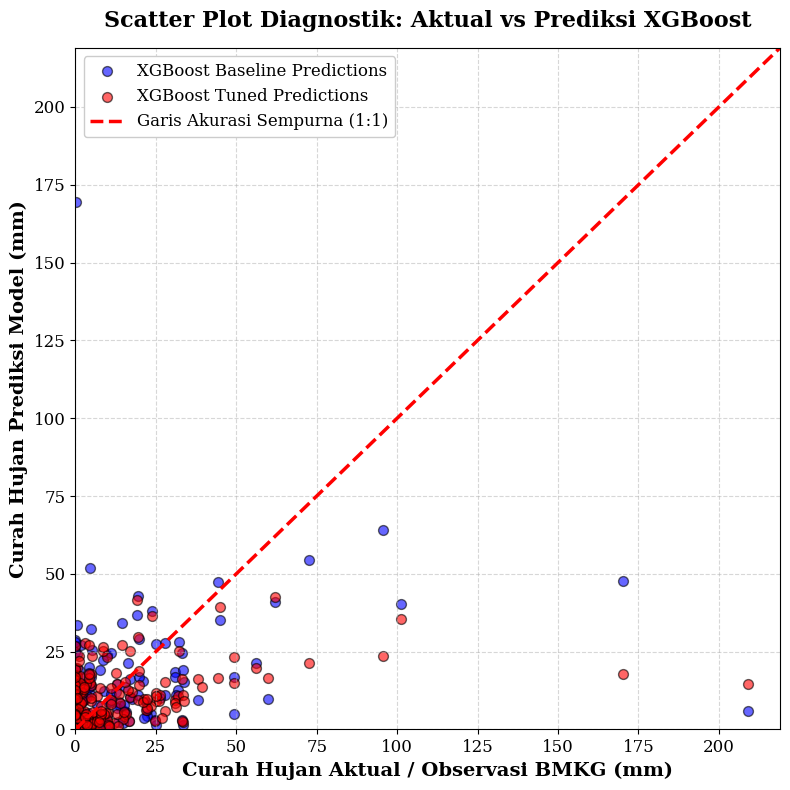


(Catatan: Visualisasi alternatif Bar-Line dan Scatter Plot resolusi HD telah disimpan dan siap diunggah ke PPT)


In [ ]:
# ---------------------------------------------------------
# OPSI 2: SCATTER PLOT 1:1 (DIAGNOSTIK MODEL)
# ---------------------------------------------------------
plt.figure(figsize=(8, 8)) # Proporsi persegi lebih baik untuk scatter 1:1

# Plot titik sebaran (seluruh data test 2022)
# Plot for XGBoost Baseline
plt.scatter(actual_xgb, pred_xgb_base, color='blue', alpha=0.6, edgecolor='black', s=50, label='XGBoost Baseline Predictions')
# Plot for XGBoost Tuned
plt.scatter(actual_xgb, pred_xgb_tune, color='red', alpha=0.6, edgecolor='black', s=50, label='XGBoost Tuned Predictions')


# Buat garis 1:1 (Garis Sempurna)
max_val = max(max(actual_xgb), max(pred_xgb_base), max(pred_xgb_tune)) + 10
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2.5, label='Garis Akurasi Sempurna (1:1)')

plt.title('Scatter Plot Diagnostik: Aktual vs Prediksi XGBoost', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Curah Hujan Aktual / Observasi BMKG (mm)', fontsize=14, fontweight='bold')
plt.ylabel('Curah Hujan Prediksi Model (mm)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Mengatur limit sumbu agar persegi presisi
plt.xlim(0, max_val)
plt.ylim(0, max_val)

plt.legend(fontsize=12, loc='upper left', framealpha=1.0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Scatter_1_to_1_XGBoost_PPT.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n(Catatan: Visualisasi alternatif Bar-Line dan Scatter Plot resolusi HD telah disimpan dan siap diunggah ke PPT)")

#Modif LSTM

In [ ]:
# ==================================================
# 2. LSTM Baseline + Tuning (Revisi Arsitektur)
# ==================================================
print("\n=== LSTM BASELINE ===")

# Arsitektur direvisi
def build_lstm(input_shape, units1=50, units2=25, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential()
    # Layer 1
    model.add(LSTM(units1, input_shape=input_shape, return_sequences=True))
    model.add(Dropout(dropout_rate))

    # Layer 2
    model.add(LSTM(units2, return_sequences=False))
    model.add(Dropout(dropout_rate))

    # Output Layer: Gunakan aktivasi 'relu' agar hasil curah hujan tidak pernah minus (< 0)
    model.add(Dense(1, activation='relu'))

    # Gunakan Huber Loss: Jauh lebih baik dari MSE untuk data dengan lonjakan ekstrem (hujan lebat)
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss=tf.keras.losses.Huber(),
                  metrics=['mae'])
    return model

# Pastikan X_train_seq sudah dibentuk ulang menggunakan look_back = 3
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
lstm_baseline = build_lstm(input_shape, units1=64, units2=32, dropout_rate=0.2, learning_rate=0.001)

# Tambahkan patience pada EarlyStopping agar model punya waktu belajar pola ekstrem
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = lstm_baseline.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[early_stop],
    verbose=1
)

# Prediksi baseline
y_pred_train_lstm_baseline = lstm_baseline.predict(X_train_seq).flatten()
y_pred_val_lstm_baseline = lstm_baseline.predict(X_val_seq).flatten()
y_pred_test_lstm_baseline = lstm_baseline.predict(X_test_seq).flatten()

print("\nEvaluasi LSTM baseline (pada data sequence):")
evaluate(pd.Series(y_train_seq), y_pred_train_lstm_baseline, "LSTM Baseline - Train")
evaluate(pd.Series(y_val_seq), y_pred_val_lstm_baseline, "LSTM Baseline - Val")
evaluate(pd.Series(y_test_seq), y_pred_test_lstm_baseline, "LSTM Baseline - Test")




=== LSTM BASELINE ===
Epoch 1/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0021 - mae: 0.0230 - val_loss: 0.0026 - val_mae: 0.0256
Epoch 2/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0021 - mae: 0.0225 - val_loss: 0.0026 - val_mae: 0.0256
Epoch 3/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0021 - mae: 0.0225 - val_loss: 0.0026 - val_mae: 0.0256
Epoch 4/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0021 - mae: 0.0225 - val_loss: 0.0026 - val_mae: 0.0256
Epoch 5/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0021 - mae: 0.0225 - val_loss: 0.0026 - val_mae: 0.0256
Epoch 6/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0021 - mae: 0.0225 - val_loss: 0.0026 - val_mae: 0.0256
Epoch 7/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0021 - mae: 0.0225 - val_loss: 0.0026 - val_mae: 0.0256
Epoch 8/100
331/331 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0021 - mae: 0.0225 - val_loss: 0.0026 - val_mae: 0.0256
Epoch 9/100
331/

(np.float64(20.287449894687644),
 6.942209631728045,
 -0.1326254405229057,
 np.float64(nan))

In [ ]:
# ==================================================
# Tuning Sederhana LSTM
# ==================================================
print("\n=== LSTM HYPERPARAMETER TUNING ===")
# Penyesuaian grid: units dibuat agak lebih besar untuk menangkap kerumitan variabel atmosfer
param_grid_lstm = [
    {'units1': 64, 'units2': 32, 'dropout': 0.2, 'lr': 0.001},
    {'units1': 128, 'units2': 64, 'dropout': 0.3, 'lr': 0.001},
    {'units1': 64, 'units2': 32, 'dropout': 0.2, 'lr': 0.0005}
]

best_val_loss = np.inf
best_lstm_model = None
best_params = None

for params in param_grid_lstm:
    print(f"\nMencoba units1={params['units1']}, units2={params['units2']}, dropout={params['dropout']}, lr={params['lr']}")
    model = build_lstm(input_shape, params['units1'], params['units2'], params['dropout'], params['lr'])

    h = model.fit(
        X_train_seq, y_train_seq,
        epochs=80,
        batch_size=32,
        validation_data=(X_val_seq, y_val_seq),
        callbacks=[early_stop], # early stop pakai 15 patience
        verbose=0
    )
    val_loss = min(h.history['val_loss'])
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_lstm_model = model
        best_params = params
        print(f"  -> Model baru terbaik dengan val_loss={val_loss:.6f}")

print(f"\nParameter LSTM terbaik: {best_params}")


=== LSTM HYPERPARAMETER TUNING ===

Mencoba units1=64, units2=32, dropout=0.2, lr=0.001
  -> Model baru terbaik dengan val_loss=0.002584

Mencoba units1=128, units2=64, dropout=0.3, lr=0.001

Mencoba units1=64, units2=32, dropout=0.2, lr=0.0005

Parameter LSTM terbaik: {'units1': 64, 'units2': 32, 'dropout': 0.2, 'lr': 0.001}


## Perbandingan XGBoost vs. LSTM

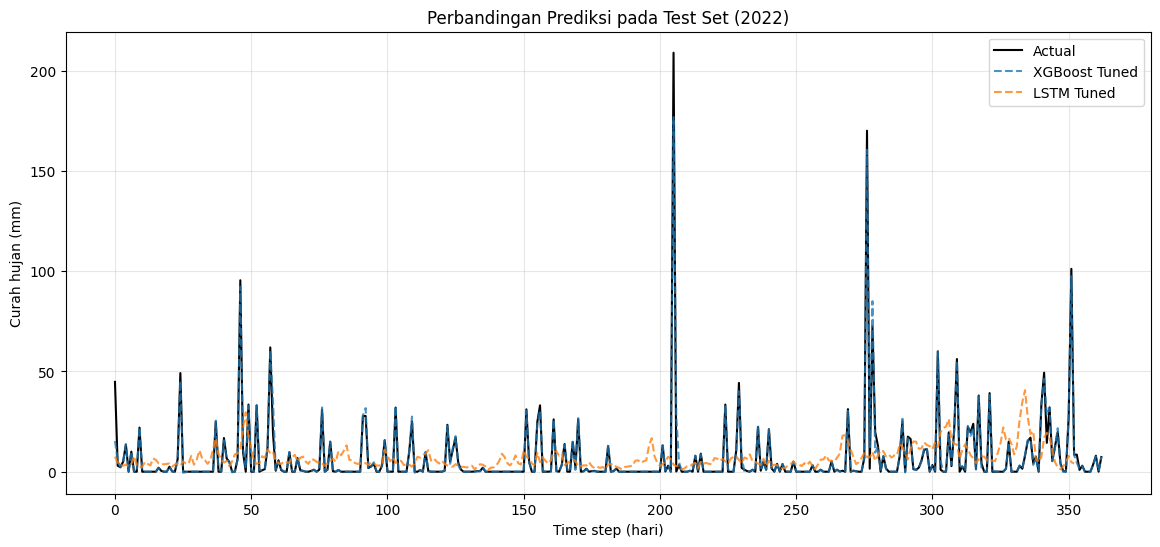

In [ ]:
# Plot perbandingan pada test set (XGBoost vs LSTM)
plt.figure(figsize=(14,6))
plt.plot(y_test_actual, label='Actual', color='black', linewidth=1.5)
plt.plot(y_test_pred_xgb, label='XGBoost Tuned', linestyle='--', alpha=0.8)
plt.plot(y_test_pred_lstm, label='LSTM Tuned', linestyle='--', alpha=0.8)
plt.title('Perbandingan Prediksi pada Test Set (2022)')
plt.xlabel('Time step (hari)')
plt.ylabel('Curah hujan (mm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Visualisasi Ekstrem

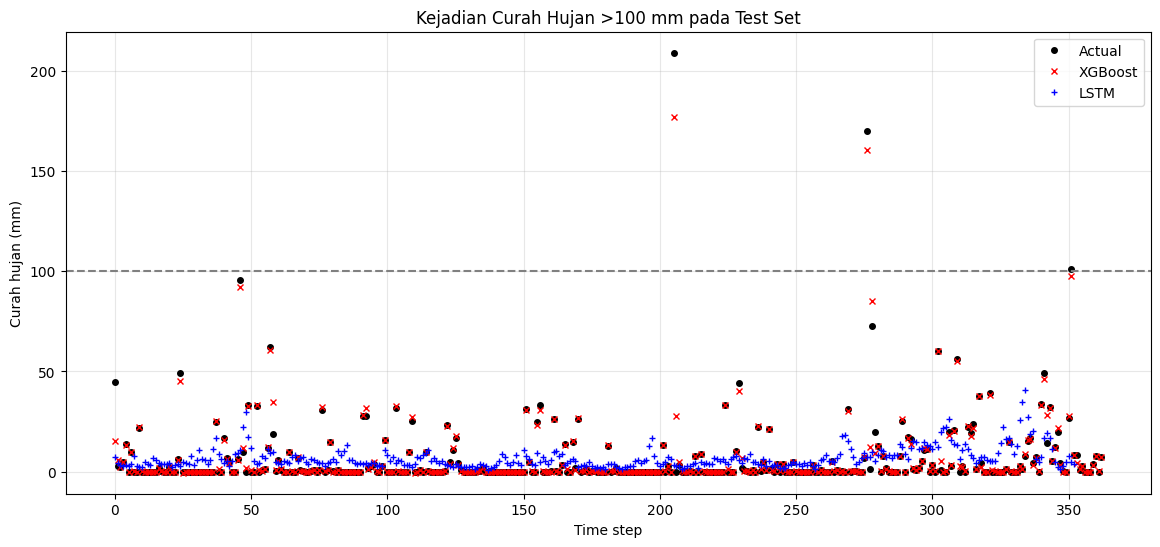

In [ ]:
# Fokus pada periode ekstrem (misal hujan > 100 mm)
plt.figure(figsize=(14,6))
# Tampilkan hanya di atas 100 mm agar terlihat ekstrem
threshold_plot = 100
mask_actual = y_test_actual > threshold_plot
mask_xgb = y_test_pred_xgb > threshold_plot
mask_lstm = y_test_pred_lstm > threshold_plot
plt.plot(y_test_actual, 'ko', markersize=4, label='Actual')
plt.plot(y_test_pred_xgb, 'rx', markersize=4, label='XGBoost')
plt.plot(y_test_pred_lstm, 'b+', markersize=4, label='LSTM')
plt.axhline(y=threshold_plot, color='gray', linestyle='--')
plt.title('Kejadian Curah Hujan >100 mm pada Test Set')
plt.xlabel('Time step')
plt.ylabel('Curah hujan (mm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Evaluasi Model

In [ ]:
# ==================================================
# 4. Evaluasi tambahan untuk kejadian ekstrem (hitung error pada hari ekstrem)
# ==================================================
print("\n=== EVALUASI PADA KEJADIAN EKSTREM (RAIN >150 mm di Test Set) ===")
from sklearn.metrics import mean_absolute_error

# Align y_test_actual and y_test_pred_xgb to the length of LSTM predictions
# LSTM predictions are made for y_test_seq, which has look_back fewer elements
# The corresponding actual values for LSTM predictions are y_test_actual_seq (which is already 354 elements long)

y_test_actual_eval = y_test_actual_seq
y_test_pred_xgb_eval = y_test_pred_xgb[look_back:] # Truncate XGBoost predictions to match LSTM length

extreme_mask = y_test_actual_eval > 150 # Create mask based on the aligned actuals
if np.sum(extreme_mask) > 0:
    y_test_extreme = y_test_actual_eval[extreme_mask]
    y_pred_xgb_extreme = y_test_pred_xgb_eval[extreme_mask]
    y_pred_lstm_extreme = y_test_pred_lstm[extreme_mask]

    print(f"Jumlah hari ekstrem di test set: {np.sum(extreme_mask)}")
    print("MAE pada hari ekstrem - XGBoost:", mean_absolute_error(y_test_extreme, y_pred_xgb_extreme))
    print("MAE pada hari ekstrem - LSTM:", mean_absolute_error(y_test_extreme, y_pred_lstm_extreme))

    # Tampilkan detail
    # Get the dates corresponding to the LSTM prediction period for printing
    # 'df_scaled[test_mask]['date']' contains dates for the full 364 days of the test set
    # We need to slice it to match the 354 days of the LSTM predictions.
    test_dates_for_eval = df_scaled[test_mask]['date'].iloc[look_back:].reset_index(drop=True)

    # np.where(extreme_mask)[0] gives the indices within the 354-element aligned array that are extreme
    for i in np.where(extreme_mask)[0]:
        date_of_extreme = test_dates_for_eval.iloc[i]
        # Access the values directly from the (354-length) aligned arrays using index 'i'
        print(f"Tanggal {date_of_extreme.strftime('%Y-%m-%d')} (indeks relatif {i}): Aktual={y_test_actual_eval[i]:.1f}, XGB={y_test_pred_xgb_eval[i]:.1f}, LSTM={y_test_pred_lstm[i]:.1f}")
else:
    print("Tidak ada kejadian ekstrem >150 mm di test set.")

print("\n=== SEMUA PROSES MODELING SELESAI ===")


=== EVALUASI PADA KEJADIAN EKSTREM (RAIN >150 mm di Test Set) ===
Jumlah hari ekstrem di test set: 2
MAE pada hari ekstrem - XGBoost: 20.83553009033203
MAE pada hari ekstrem - LSTM: 182.19646816253663
Tanggal 2022-07-26 (indeks relatif 195): Aktual=209.0, XGB=176.9, LSTM=5.7
Tanggal 2022-10-05 (indeks relatif 266): Aktual=170.1, XGB=160.6, LSTM=9.0

=== SEMUA PROSES MODELING SELESAI ===


#Coding lama

In [ ]:
!pip install scikeras tensorflow xgboost openpyxl

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import L1L2
from tensorflow.keras.callbacks import EarlyStopping

Read data bmkg

In [ ]:
# %% Baca Data
# Data observasi dari Stasiun Maliku Saleh (Aceh)
df_obs = pd.read_excel('aceh_df.xlsx')
print("Data observasi (aceh_df) - shape:", df_obs.shape)
print(df_obs.head())

FileNotFoundError: [Errno 2] No such file or directory: 'aceh_df.xlsx'

Read data era5

In [ ]:
# Data reanalisis ERA5 (ClimateEngine) - titik Tamiang
df_era = pd.read_excel('ClimateEngine (1).xlsx')
print("\nData reanalisis ERA5 - shape:", df_era.shape)
print(df_era.head())

**Pre-proces data**

In [ ]:
# Konversi kolom tanggal ke datetime
df_obs['date'] = pd.to_datetime(df_obs['date'])
df_era['Date'] = pd.to_datetime(df_era['Date'])

# Gabungkan berdasarkan tanggal (gunakan inner join agar tanggal sinkron)
df = pd.merge(df_obs, df_era, left_on='date', right_on='Date', how='inner')
print("\nData setelah digabung - shape:", df.shape)
print(df.columns)

# Pilih kolom yang relevan: date, rain (target), tmin, tmax, tavg, RH, CH (curah hujan reanalisis)
df = df[['date', 'rain', 'tmin', 'tmax', 'tavg', 'RH', 'CH']].copy()
df.rename(columns={'rain': 'RAIN', 'CH': 'ERA5_RAIN'}, inplace=True)


Cek missing data

In [ ]:
# Cek missing values
print("\nMissing values per kolom:")
print(df.isnull().sum())

# Tidak ada NA (sesuai info user)
print("Jumlah data:", len(df))
print("Periode:", df['date'].min(), "sampai", df['date'].max())

In [ ]:
# %% Eksplorasi sederhana
plt.figure(figsize=(12,4))
plt.plot(df['date'], df['RAIN'], label='Observasi (rain)', alpha=0.7)
plt.plot(df['date'], df['ERA5_RAIN'], label='ERA5 CH', alpha=0.7)
plt.legend()
plt.title('Curah Hujan Observasi vs Reanalisis ERA5 (Tamiang)')
plt.ylabel('mm/hari')
plt.show()

Lag features

In [ ]:
# %% Fungsi membuat lag features (hanya untuk target, seperti di praktikum)
def make_lags(data, col, lag_range):
    """
    Membuat fitur lag dari kolom target.
    data: DataFrame dengan kolom tanggal dan target
    col: nama kolom target
    lag_range: range(1, n+1)
    """
    df_lag = data[['date', col]].copy()
    df_lag.rename(columns={col: 'TARGET'}, inplace=True)
    for lag in lag_range:
        df_lag[f'TARGET_lag{lag}'] = df_lag['TARGET'].shift(lag)
    return df_lag.dropna()

In [ ]:
# Tentukan jumlah lag (coba 10, bisa disesuaikan)
lag = 10
lag_range = range(1, lag+1)
df_target_lags = make_lags(df, 'RAIN', lag_range)
print("Shape setelah lag features:", df_target_lags.shape)

In [ ]:
df_other = df[['date', 'tmin', 'tmax', 'tavg', 'RH', 'ERA5_RAIN']].copy()
# Potong sesuai index df_target_lags (karena lag menghilangkan beberapa baris awal)
df_other_aligned = df_other.iloc[lag:]  # karena lag pertama mulai dari baris ke-lag+1
df_other_aligned.reset_index(drop=True, inplace=True)
df_target_lags.reset_index(drop=True, inplace=True)

Gabungan data

In [ ]:
# Gabungkan
final_df = pd.concat([df_target_lags, df_other_aligned.drop('date', axis=1)], axis=1)
print("Final dataset shape:", final_df.shape)
print(final_df.head())

Min-max scalling

In [ ]:
# %% Normalisasi MinMax
# Pisahkan kolom target (TARGET) dengan fitur lainnya
target_col = 'TARGET'
feature_cols = [c for c in final_df.columns if c != target_col and c != 'date']

# Simpan min/max untuk inverse scaling nanti
minp = final_df[target_col].min()
maxp = final_df[target_col].max()

# Normalisasi semua kolom
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(final_df[feature_cols + [target_col]])
scaled_df = pd.DataFrame(scaled_data, columns=feature_cols + [target_col])
scaled_df['date'] = final_df['date'].values

target dan fitur

In [ ]:
# Target dan fitur
X = scaled_df[feature_cols]
y = scaled_df[target_col]

print("X shape:", X.shape, "y shape:", y.shape)

# %% Split data (time-series aware: urutan waktu)
def split_timeseries(X, y, train_ratio=0.9):
    n = len(X)
    train_size = int(n * train_ratio)
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
    print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = split_timeseries(X, y, train_ratio=0.9)

**XGBoost**

In [ ]:
print("\n=== XGBoost ===")
xgb_model = XGBRegressor(n_estimators=500, random_state=42)
xgb_model.fit(X_train, y_train)

# Prediksi
train_pred_xgb = xgb_model.predict(X_train)
test_pred_xgb = xgb_model.predict(X_test)

# Inverse scaling
train_pred_xgb_unscaled = train_pred_xgb * (maxp - minp) + minp
test_pred_xgb_unscaled = test_pred_xgb * (maxp - minp) + minp
y_train_unscaled = y_train * (maxp - minp) + minp
y_test_unscaled = y_test * (maxp - minp) + minp

# Evaluasi
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    cc = np.corrcoef(y_true, y_pred)[0,1]
    print(f"{name} - RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}, CC: {cc:.2f}")
    return rmse, mae, r2, cc

print("XGBoost - Training:")
evaluate(y_train_unscaled, train_pred_xgb_unscaled, "Train")
print("XGBoost - Testing:")
evaluate(y_test_unscaled, test_pred_xgb_unscaled, "Test")

In [ ]:
# Plot
plt.figure(figsize=(12,5))
plt.plot(y_test_unscaled.values, label='Actual', alpha=0.7)
plt.plot(test_pred_xgb_unscaled, label='XGBoost Pred', alpha=0.7)
plt.title('XGBoost: Prediksi vs Aktual (Data Uji)')
plt.xlabel('Time step')
plt.ylabel('Curah Hujan (mm)')
plt.xlim(0,300)
plt.legend()
plt.show()

**Random forest**

In [ ]:
print("\n=== Random Forest ===")
rf_model = RandomForestRegressor(n_estimators=500, random_state=42)
rf_model.fit(X_train, y_train)

train_pred_rf = rf_model.predict(X_train)
test_pred_rf = rf_model.predict(X_test)

train_pred_rf_unscaled = train_pred_rf * (maxp - minp) + minp
test_pred_rf_unscaled = test_pred_rf * (maxp - minp) + minp

print("Random Forest - Training:")
evaluate(y_train_unscaled, train_pred_rf_unscaled, "Train")
print("Random Forest - Testing:")
evaluate(y_test_unscaled, test_pred_rf_unscaled, "Test")

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test_unscaled.values, label='Actual', alpha=0.7)
plt.plot(test_pred_rf_unscaled, label='RF Pred', alpha=0.7)
plt.title('Random Forest: Prediksi vs Aktual (Data Uji)')
plt.xlabel('Time step')
plt.ylabel('Curah Hujan (mm)')
plt.xlim(0,300)
plt.legend()
plt.show()

**LSTM**

In [ ]:
print("\n=== LSTM ===")
# Untuk LSTM, kita perlu data dalam bentuk sequence (look_back)
# Gunakan data yang sudah dinormalisasi, buat sequence dengan look_back = 10
look_back = 10

def create_sequences(data_x, data_y, look_back):
    X_seq, y_seq = [], []
    for i in range(len(data_x) - look_back):
        X_seq.append(data_x.iloc[i:i+look_back].values)
        y_seq.append(data_y.iloc[i+look_back])
    return np.array(X_seq), np.array(y_seq)

X_seq_train, y_seq_train = create_sequences(X_train, y_train, look_back)
X_seq_test, y_seq_test = create_sequences(X_test, y_test, look_back)

print("LSTM input shape:", X_seq_train.shape, "output shape:", y_seq_train.shape)

In [ ]:
# Arsitektur LSTM (sederhana)
model_lstm = Sequential()
model_lstm.add(LSTM(50, input_shape=(look_back, X_train.shape[1]), return_sequences=True))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(25, return_sequences=False))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_lstm.fit(X_seq_train, y_seq_train, epochs=100, batch_size=32,
                         validation_split=0.2, callbacks=[early_stop], verbose=1)

# Prediksi
train_pred_lstm = model_lstm.predict(X_seq_train).flatten()
test_pred_lstm = model_lstm.predict(X_seq_test).flatten()

# Inverse scaling untuk LSTM (perlu menyesuaikan indeks karena sequence)
y_train_seq_unscaled = y_seq_train * (maxp - minp) + minp
y_test_seq_unscaled = y_seq_test * (maxp - minp) + minp
train_pred_lstm_unscaled = train_pred_lstm * (maxp - minp) + minp
test_pred_lstm_unscaled = test_pred_lstm * (maxp - minp) + minp

print("LSTM - Training:")
evaluate(y_train_seq_unscaled, train_pred_lstm_unscaled, "Train")
print("LSTM - Testing:")
evaluate(y_test_seq_unscaled, test_pred_lstm_unscaled, "Test")

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test_seq_unscaled, label='Actual', alpha=0.7)
plt.plot(test_pred_lstm_unscaled, label='LSTM Pred', alpha=0.7)
plt.title('LSTM: Prediksi vs Aktual (Data Uji)')
plt.xlabel('Time step')
plt.ylabel('Curah Hujan (mm)')
plt.xlim(0,300)
plt.legend()
plt.show()